In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
#from rule_mining import mine_rules_preprocessing
import os 
from HybridCORELS import HybridCORELSPreClassifier, HybridCORELSPostClassifier
from HyRS import HybridRuleSetClassifier
from companion_rule_list import CRL
import pickle


def age_data_modification(X,features):
    """modify dataset to have mutually exclusive age groups"""
    df_x = pd.DataFrame(X, columns=features)
    df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
    df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
    df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
    df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)
    return np.array(df_x), df_x.columns.tolist()


def get_data(dataset, splits, max_card=2, min_support=1, n_rules=300, random_state_param=42):
    # # Generate the acs_data if it is not already there
    # if dataset == "acs_employ":# and not os.path.exists(f"data/{dataset}.csv"):
    #     generate_acs_data()

    # Mine the dataset set if it has not already been done
    if not os.path.exists(f"data/{dataset}_mined.csv"):

        df = pd.read_csv(f"data/{dataset}.csv", sep = ',')
        X = df.iloc[:, :-1]
        prediction = df.iloc[:, -1].name
        y = np.array(df.iloc[:, -1])

        # Mine the rules
        #X = mine_rules_preprocessing(X, y, max_card, min_support, n_rules) #uncomment when you need rulemining (DONE by ZIba)
        features = list(X.columns)
        X = np.array(X)

        # Save the dataset
        df = pd.DataFrame(np.column_stack((X, y)), columns=features+[prediction])
        df.to_csv(f"data/{dataset}_mined.csv", encoding='utf-8', index=False)

    # Rules have already been mined
    else:
        df = pd.read_csv(f"data/{dataset}_mined.csv", sep = ',')
        X = df.iloc[:, :-1]
        features = list(X.columns)
        X = np.array(X)
        prediction = df.iloc[:, -1].name
        y = np.array(df.iloc[:, -1])


    # Generate splits
    assert len(splits) <= 3, "We only support splitting the data to up to 3 folds"
    split_names = list(splits.keys())
    split_ratios = list(splits.values())
    assert np.sum(split_ratios) == 1, "The split ratios must sum up to one"
    X_dict = {}
    y_dict = {}
    X_1, X_2, y_1, y_2 = train_test_split(X, y, train_size=split_ratios[0],
                                          shuffle=True, random_state=random_state_param)
    X_dict[split_names[0]] = X_1
    y_dict[split_names[0]] = y_1
    if len(splits) == 2:
        X_dict[split_names[1]] = X_2
        y_dict[split_names[1]] = y_2
    else:
        sub_ratio = split_ratios[1] / (split_ratios[1] + split_ratios[2])
        X_2, X_3, y_2, y_3 = train_test_split(X_2, y_2, train_size=sub_ratio,
                                          shuffle=True, random_state=random_state_param)
        X_dict[split_names[1]] = X_2
        y_dict[split_names[1]] = y_2
        X_dict[split_names[2]] = X_3
        y_dict[split_names[2]] = y_3
    return X_dict, y_dict, features, prediction



def get_data_norulemining(dataset, splits, max_card=2, min_support=1, n_rules=300, random_state_param=42):
    # # Generate the acs_data if it is not already there
    # if dataset == "acs_employ":# and not os.path.exists(f"data/{dataset}.csv"):
    #     generate_acs_data()


    df = pd.read_csv(f"data/{dataset}_mined.csv", sep = ',')
    X = df.iloc[:, :-1]
    features = list(X.columns)
    X = np.array(X)
    prediction = df.iloc[:, -1].name
    y = np.array(df.iloc[:, -1])

    #compasdatasets need to be modified to have all age sections (DONE BY ZIBA)
    if dataset == 'compas':
        X, features = age_data_modification(X,features)


    # Generate splits
    assert len(splits) <= 3, "We only support splitting the data to up to 3 folds"
    split_names = list(splits.keys())
    split_ratios = list(splits.values())
    assert np.sum(split_ratios) == 1, "The split ratios must sum up to one"
    X_dict = {}
    y_dict = {}
    X_1, X_2, y_1, y_2 = train_test_split(X, y, train_size=split_ratios[0],
                                          shuffle=True, random_state=random_state_param)
    X_dict[split_names[0]] = X_1
    y_dict[split_names[0]] = y_1
    if len(splits) == 2:
        X_dict[split_names[1]] = X_2
        y_dict[split_names[1]] = y_2
    else:
        sub_ratio = split_ratios[1] / (split_ratios[1] + split_ratios[2])
        X_2, X_3, y_2, y_3 = train_test_split(X_2, y_2, train_size=sub_ratio,
                                          shuffle=True, random_state=random_state_param)
        X_dict[split_names[1]] = X_2
        y_dict[split_names[1]] = y_2
        X_dict[split_names[2]] = X_3
        y_dict[split_names[2]] = y_3
    return X_dict, y_dict, features, prediction

def to_df(X, features):
    df_X = {}
    for key, val in X.items():
        df_X[key] = pd.DataFrame(val, columns=features)
    return df_X

def computeAccuracyUpperBound(X, y, verbose=0):
    import pandas as pd
    import numpy as np
    """
    Parameters
    ----------
    X : Features vector
    y : Labels vector
    verbose : Int
    0 -> No display
    1 -> Minimal Display
    1 -> Debug (also performs additional checks)
    Returns
    -------
    Int, Array, Array
    Int : Minimum number of instances that can not be classified correctly due to dataset inconsistency
    Array of e_r: for each inconsistent group of examples r, e_r is a representative example of this group (its index in X)
    Array of k_r: k_r is the minimum number of instances that can not be classified correctly due to dataset inconsistency, among group r
    Array of i_r: all instances that will be misclassified in the best case (for all inconsistent group, those representing minority for their label)
    """
    representatives = []
    cardinalities = []
    misclassified = []
    values, counts = np.unique(X, axis=0, return_counts=True)
    values = values[counts > 1]
    counts = counts[counts > 1]
    if verbose >= 1:
        print("Found ", values.shape[0], " unique duplicates.")
    incorrCnt = 0
    for ii, anEl in enumerate(list(values)):
        occurences = np.where((X == anEl).all(axis=1))
        representant = occurences[0][0]
        if verbose >= 2:
            print("Value ", anEl, " appears ", counts[ii], " times. (CHECK = ", occurences[0].shape[0], ")")
            print("Occurences: ", occurences, "(representant is instance#", representant, ")")
            # Additional check
            if counts[ii] != occurences[0].shape[0]:
                exit(-1)
        labels = y[occurences[0]]
        if verbose >= 2:
            print(labels)
            # Additional check
            els = X[occurences[0]]
            elsC = np.unique(els, axis=0, return_counts=True)
            if elsC[0].shape[0] > 1:
                exit(-1)
        labelsData = np.unique(labels, return_counts = True)
        if labelsData[0].size > 1:
            if labelsData[0].size != 2: # only two possible values as we work with binary labels -> this case should never happen
                exit(-1)
            minErrors = np.min(labelsData[1])
            if labelsData[1][0] == minErrors: # less 0's
                indicesInLabels = np.where((labels == 0))
                indicesX = occurences[0][indicesInLabels]
                misclassified.extend(indicesX)
                if verbose >= 2:
                    print("Less zeros!")
                    print("associated id label:", indicesInLabels)              
                    print("associated X ids:", indicesX)
            elif labelsData[1][1] == minErrors: # less 1's
                indicesInLabels = np.where((labels == 1))
                indicesX = occurences[0][indicesInLabels]
                misclassified.extend(indicesX)
                if verbose >= 2:
                    print("Less ones!")
                    print("associated id label:", indicesInLabels)     
                    print("associated X ids:", indicesX)
            else:
                print("internal error, exiting")
                exit(-1)
            if verbose >= 2:
                print("min errors possible : ", minErrors)
            incorrCnt += minErrors
            representatives.append(representant)
            cardinalities.append(minErrors)
            #print("Representant = ", representant, ", min errors = ", minErrors)
        else:
            if verbose >= 2:
                print("no inconsistency")
    if verbose >= 1:
        print("At least ", incorrCnt, " elements can not be classified correctly.")
        print("accuracy upper bound = 1 - ", incorrCnt, "/", X.shape[0], " (", 1.0-(incorrCnt/X.shape[0]), ")")        
    return 1.0-(incorrCnt/X.shape[0])

#ALL from utils (you should modify it)
import json
from pathlib import Path
import pandas as pd
import numpy as np


Data_dir = Path('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/')

def read_json(datadir):
    with open(datadir, 'r') as f:
        return json.load(f)

def save_json(data, filename):
    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

def age_data_modification(X,features):
    """modify dataset to have mutually exclusive age groups"""
    df_x = pd.DataFrame(X, columns=features)
    df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
    df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
    df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
    df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)
    return np.array(df_x), df_x.columns.tolist()


class DemographicData():
    def __init__(self, X,y, features, condition):
        self.X = X
        self.features = features
        self.condition = condition
        self.y = y
    
    def filter_data(self):
        filtered_data = self.X[:, [i for i,j in enumerate(self.features) if j in self.condition]]
        if len (self.condition)==1:
            filtered_data = filtered_data.ravel()
        return filtered_data
    
    def get_condition_freq(self):
        condition_count = self.filter_data().sum(axis=0)
        freq = (condition_count/self.X.shape[0])*100
        return dict(zip(self.condition, freq))

    def corr_subgroups(self):
        correlation= {}
        for i,j in enumerate(self.condition):
            corr = np.corrcoef(self.y,self.filter_data()[:,i])[0,1]
            correlation[j]=corr
        return correlation




# faireness evaluation add by ziba

class FairnessMeasure():
    def __init__(self,X ,features: list, condition:list):
        """
        This class computes fairness measures based on transparency for a given condition.
        X: np.ndarray
            it could be train or test data.
        features: list
            List of feature names corresponding to the columns of X.
        condition: list
            List of feature names that define the condition. The condition is the intersection of these features being true (1)."""
        self.X = X
        self.features = features
        self.condition = condition
        self.cond_indices = self.set_condition()
    #slice the data based on the condition
    def set_condition(self):  
        indices_of_features = [i for i,j in enumerate(self.features) if j in self.condition]
        condition_indices = np.all((self.X[:,indices_of_features]),axis=1)
        return condition_indices
    
    #get frequency of a condition 
    def get_condition_freq (self):
       return float((self.set_condition().sum()/self.X.shape[0])*100)
    
    # compute of percentage of interpretable samples for the given condition
    def compute_fairness(self, preds_types):
        condition_indices = self.cond_indices

        total_count = condition_indices.sum() # total number of samples satisfying the condition
        interpretable_count = preds_types[condition_indices].sum() # number of samples satisfying the condition going through the interpretable part
        percentage_interpretable = (interpretable_count / total_count) * 100 if total_count > 0 else 0
        return {
            "condition": self.condition,
            "total_count": int(total_count),
            "interpretable_count": int(interpretable_count),
            "percentage_interpretable": float(percentage_interpretable)#'%.2f' % percentage_interpretable
        }
    

    def confusion_matrix(self, pred, y_true, pred_types, cond_indices, detailed = True):
        """This fucntions return the confusion matrix for each condition 
        and for both interpretable and black box part

        Args:
            pred (numpy array): output prediction
            y_true (numpy array): target label
            pred_types (numpy array): an array that shows if an instance is interpreted by rule list or by the BB
            cond_indices (numpy array): indices of instaces of a subgroup
            detailed (bool, optional): True if a detailed confusion matrix per interpretable and BB is wanted. Defaults to False.
        """
        if detailed:
            TP_interpret= np.sum((y_true[cond_indices]==pred[cond_indices])
                                        & (y_true[cond_indices]==1)& (pred_types[cond_indices]==1))
            TP_BB = np.sum((y_true[cond_indices]==pred[cond_indices])
                                        & (y_true[cond_indices]==1)& (pred_types[cond_indices]==0))
            TN_interpret = np.sum((y_true[cond_indices]==pred[cond_indices]) & (y_true[cond_indices]==0) 
                                        & (pred_types[cond_indices]==1))
            TN_BB = np.sum((y_true[cond_indices]==pred[cond_indices]) & (y_true[cond_indices]==0) 
                                        & (pred_types[cond_indices]==0))
            FP_interpret = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==1)
                                        & (pred_types[cond_indices]==1))
            FP_BB = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==1)
                                        & (pred_types[cond_indices]==0))
            FN_interpret = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==0)
                                        & (pred_types[cond_indices]==1))
            FN_BB = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==0)
                                        & (pred_types[cond_indices]==0))
            return {'Interpretable':np.array([[TN_interpret, FP_interpret],
                                    [FN_interpret, TP_interpret]]), 'Blackbox': np.array([[TN_BB,FP_BB],
                                    [FN_BB, TP_BB]])}
        else:
            TP = np.sum((y_true[cond_indices]==pred[cond_indices]) & (y_true[cond_indices]==1))
            TN = np.sum((y_true[cond_indices]==pred[cond_indices]) & (y_true[cond_indices]==0))
            FP = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==1))
            FN = np.sum((y_true[cond_indices]!=pred[cond_indices]) & (pred[cond_indices]==0))

            print("Confusion Matrix")
            print("----------------")
            print(f"           \tPredicted Negative    Predicted positive")
            print(f"Actual Negative\t\t{TN:4d}\t      {FP:4d}")
            print(f"Actual Positive\t\t{FN:4d}\t      {TP:4d}")
            return np.array([[TN, FP],
                        [FN, TP]])


#This function get the initial json data file and extract the TPR for each seed and each subgroup

def get_TPR (data):
    """This function calulates the TPR ratio from the confusion matrix

    Args:
        data (dict): a portion of data that have all conditions as key

    Returns:
        dict: a dictionary with all conditions as key 
    """
    TPR_info = {cond:{'TPR_overal':[], 'TPR_T':[], 'TPR_B':[]} for cond in data.keys()}
    for cond in data.keys(): #this is for all conditions in data
        TPR_overal=[]
        TPR_T=[]
        TPR_BB=[]
        first_metric = next (iter(data[cond]))
        n_seeds = len(data[cond][first_metric])
        for i in range(n_seeds):
            TP_overall = (data[cond]['TP']['T'][i]+ data[cond]['TP']['B'][i])
            FN_overall = (data[cond]['FN']['T'][i]+ data[cond]['FN']['B'][i])
            if (TP_overall+FN_overall) !=0:
                TPR = TP_overall/(TP_overall+FN_overall)
            else:
                TPR= 0
            TPR_overal.append(TPR)
            TP_T = data[cond]['TP']['T'][i]
            FN_T = data[cond]['FN']['T'][i]
            if (TP_T+ FN_T) !=0:
                TPR_Trans = TP_T/ (TP_T+ FN_T )
            else:
                TPR_Trans = 0
            TPR_T.append(TPR_Trans)
            TP_B = data[cond]['TP']['B'][i]
            FN_B = data[cond]['FN']['B'][i]
            if (TP_B+FN_B) != 0:
                TPR_Blackbox = TP_B / (TP_B+FN_B)
            else:
                TPR_Blackbox = 0
            TPR_BB.append(TPR_Blackbox)

        TPR_info[cond]['TPR_overal']= TPR_overal
        TPR_info[cond]['TPR_T']= TPR_T
        TPR_info[cond]['TPR_B']= TPR_BB
    return TPR_info


def compute_global_fairness (TPR_info, condition,model_part= None): # 
    """this function computes the global fairness measure which is the maximum gap 
    between TPR of each demographic group for each seed. Also we can compute the overall fairness for the Hybrid model 
    or only for the interpretable part or only for the BlackBox 

    Args:
        TPR_info (dict): This dictionary include the TPR for all conditions and all seeds
        condition (list): this is the dmographic subgroup for which we measure the fairness
        model_part (str, optional): None if overall performance is wanted, 'B' for BB fairness and 'T' for 
        interpretable part fairness . Defaults to None.

    Returns:
        numpy array: array of global fairness measure for all seeds
    """
    fairness_gaps = []
    if model_part == None:
        part = 'TPR_overal'
    elif model_part == 'T':
        part = 'TPR_T'
    elif model_part == 'B':
        part = 'TPR_B'
    first_group = next(iter(TPR_info))
    # pick the first metric key
    first_metric = next(iter(TPR_info[first_group]))
    n_seeds = len(TPR_info[first_group][first_metric])
    for i in range (n_seeds):
        gap = max([abs(TPR_info[g1][part][i] - TPR_info[g2][part][i])\
        for g1 in condition for g2 in condition if g1!= g2 ])
        fairness_gaps.append(gap)

    return np.array(fairness_gaps)
        
def compute_signed_global_fairness (TPR_info, condition,model_part): # 
    """this function computes the global fairness measure which is the maximum gap 
    between TPR of each demographic group for each seed. Also we can compute the overall fairness for the Hybrid model 
    or only for the interpretable part or only for the BlackBox 

    Args:
        TPR_info (dict): This dictionary include the TPR for all conditions and all seeds
        condition (list): this is the dmographic subgroup for which we measure the fairness
        model_part (str, optional): None if overall performance is wanted, 'B' for BB fairness and 'T' for 
        interpretable part fairness . Defaults to None.

    Returns:
        list: list of global fairness measure for all seeds
    """
    if len(condition)!=2:
        raise ValueError('Signed TPR difference is over two subgroups')
    g1 = condition[0]
    g2 = condition[1]
    fairness_gaps = []
    if model_part == None:
        part = 'TPR_overal'
    elif model_part == 'T':
        part = 'TPR_T'
    elif model_part == 'B':
        part = 'TPR_B'

    fairness_gaps = np.array(TPR_info[g1][part])-np.array(TPR_info[g2][part])
    return np.array(fairness_gaps)



def statistics (array):
    mean = np.mean(array)
    std = np.std(array)
    se = np.std(array) / np.sqrt(len(array))
    return mean, std, se


def paired_subgroups (subgroups):
    return [(x, y )for i, x in enumerate(subgroups) for y in subgroups[i+1:]]

class Dataset():
    """Class representing a dataset loaded from a csv file.
    csv file is after rule mining"""
    def __init__(self, dataset_name, X, y, features, prediction):
        self.name = dataset_name
        self.X = X
        self.features = features
        self.y = y
        self.prediction = prediction
        self.preprocessed = False
        

    def data_modification(self, dataset_name, X, features):
        """modify dataset to have mutually exclusive demographic subgroups

        Args:
            dataset_name (str): name of the dataset
            X (numpy array): initial data read from csv
            features (list): list of features names corresponding to columns of X

        Returns:
            (numpy array , list ): (modified data, modified list of features)
        """
        df_x = pd.DataFrame(X, columns=features)
        if dataset_name == 'compas':
            df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
            df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
            df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
            df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)
        elif dataset_name == 'adult':
            df_x['race_other'] = ((1-df_x['neg_race_Amer-Indian-Eskimo'] ) | (1-df_x['neg_race_Other']))
            df_x['race_Asian'] = (1- df_x['neg_race_Asian-Pac-Islander'])
        elif dataset_name == 'acs_employ':
            df_x['American Indian and Alaska Native']= (1-df_x['neg_American Indian and Alaska Native tribes specified;or American Indian or Alaska Native,not specified and no other'])
            df_x['Two or More Races'] = 1 - df_x['neg_Two or More Races']
            df_x['Alaska Native alone'] = 1 - df_x['neg_Alaska Native alone']
            df_x['Native Hawaiian and Other Pacific Islander alone'] = 1 - df_x['neg_Native Hawaiian and Other Pacific Islander alone']
            df_x['Two or More Races'] = 1 - df_x['neg_Two or More Races']
        return np.array(df_x), df_x.columns.tolist()


    @classmethod
    def load_from_csv(cls, fname, dataset_name):
        """
        Load a dataset from a csv file. The csv file must contain n_samples+1 rows, each with n_features+1
        columns. The last column of each sample is its prediction class, and the first row of the file
        contains the feature names and prediction class name.
        attention :this function is not used anymore (replaced by from_csv)
        Parameters
        ----------
        fname : str
            File name of the csv data file
        
        Returns
        -------
        X : array-like, shape = [n_samples, n_features]
            The sample data

        y : array-line, shape = [n_samples]
            The target values for the sample data
        
        features : list
            A list of strings of length n_features. Specifies the names of each of the features.

        prediction_name : str
            The name of the prediction class
        """
        import csv
        features = []
        prediction_name = ""

        with open(fname, "r") as f:
            features = f.readline().strip().split(",")
            prediction_name = features[-1]
            features = features[0:-1]

        data = np.genfromtxt(fname, dtype=np.uint8, skip_header=1, delimiter=",")

        X = data[:, 0:-1]
        y = data[:, -1]
        return cls(dataset_name, X, y, features, prediction_name)

    
    @classmethod
    def from_csv(cls, fname, dataset_name ):
        """
        Load a dataset from a csv file. The csv file must contain n_samples+1 rows, each with n_features+1
        columns. The last column of each sample is its prediction class, and the first row of the file
        contains the feature names and prediction class name.
        
        Parameters
        ----------
        fname : str
            File name of the csv data file
        
        Returns
        -------
        X : array-like, shape = [n_samples, n_features]
            The sample data

        y : array-line, shape = [n_samples]
            The target values for the sample data
        
        features : list
            A list of strings of length n_features. Specifies the names of each of the features.

        prediction_name : str
            The name of the prediction class
        """
        df = pd.read_csv(fname)
        X = df.iloc[:, :-1].to_numpy()
        y = df.iloc[:, -1].to_numpy()

        features = df.columns[:-1].tolist()
        prediction = df.columns[-1]
        return cls(dataset_name, X, y, features, prediction)


    def train_test_split(self, train_proportion, random_state):
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=1.0 - train_proportion, shuffle=True,random_state=random_state)
        X_dict = {'train': X_train, 'test':X_test }
        y_dict = {'train': y_train, 'test':y_test }
        return X_dict, y_dict
    

    def pre_process (self):
        """This method apply all modifications regarding demographic subgroups
        """
        self.X, self.features = self.data_modification(self.name, self.X, self.features)
        self.preprocessed = True


    def get_data_norulemining(self, splits, random_state_param=42):
        """This method split data to train and test set after preprocessing

        Args:
            splits (dict): example {"train" : 0.8, "test" : 0.2}
            random_state_param (int, optional):  Defaults to 42.

        Returns:
            dict: the output is X={'train':X_train,'test': X_test}
        and y={'train':y_train,'test': y_test}
        """
        # Pre-process data to add demographic groups columns
        if not self.preprocessed:
            self.pre_process()

        # Generate splits
        assert len(splits) <= 3, "We only support splitting the data to up to 3 folds"
        split_names = list(splits.keys())
        split_ratios = list(splits.values())
        assert np.sum(split_ratios) == 1, "The split ratios must sum up to one"
        X_dict = {}
        y_dict = {}
        X_1, X_2, y_1, y_2 = train_test_split(self.X, self.y, train_size=split_ratios[0],
                                            shuffle=True, random_state=random_state_param)
        X_dict[split_names[0]] = X_1
        y_dict[split_names[0]] = y_1
        if len(splits) == 2:
            X_dict[split_names[1]] = X_2
            y_dict[split_names[1]] = y_2
        else:
            sub_ratio = split_ratios[1] / (split_ratios[1] + split_ratios[2])
            X_2, X_3, y_2, y_3 = train_test_split(X_2, y_2, train_size=sub_ratio,
                                            shuffle=True, random_state=random_state_param)
            X_dict[split_names[1]] = X_2
            y_dict[split_names[1]] = y_2
            X_dict[split_names[2]] = X_3
            y_dict[split_names[2]] = y_3
        return X_dict, y_dict, self.features, self.prediction
    

    def demographicGroup(self, summarized = False):
        """define demographic groups based on dataset name"""
        if self.name == 'adult':
            condition_gender = ['gender_Male', 'gender_Female']
            condition_age = ['age_low', 'age_middle', 'age_high']
            if not summarized :
                condition_race = ['race_White', 'race_Black', 'race_Asian', 'race_other']
            else:
                condition_race = ['race_White', 'race_Black','other']
        if self.name == 'compas':
            condition_gender = ['Gender=Male', 'neg_Gender=Male']
            condition_age = ['Age=18-25','Age=26-29','Age>=30']
            if not summarized:
                condition_race = ['Race=African-American', 'Race=Caucasian', 'Race=Hispanic', 'Race=Other']
            else:
                condition_race = ['Race=African-American', 'Race=Caucasian', 'other']
        if self.name == 'acs_employ':
            condition_gender = ['neg_Female','Female' ]
            condition_age = ['age_low','age_medium', 'age_high' ]
            if not summarized :
                condition_race = ['White alone','Black or African American alone','Asian alone','Some Other Race alone',\
                            'Two or More Races','American Indian and Alaska Native','Native Hawaiian and Other Pacific Islander alone']
            else:
                condition_race = ['White alone','Black or African American alone','other']
        return {'Age': condition_age,
                'Gender': condition_gender,
                'Race': condition_race,
                'All':condition_age+condition_gender+condition_race}
    

    def filter_subgroup_data(self,condition):
        """filter data for specific subgroup condition"""  
        filtered_data = self.X[:, [i for i,j in enumerate(self.features) if j in condition]]
        if len (condition)==1:
            filtered_data = filtered_data.ravel()
        return filtered_data


    def get_condition_freq(self, condition):
        condition_count = self.filter_subgroup_data(condition).sum(axis=0)
        freq = (condition_count/self.X.shape[0])*100
        return dict(zip(condition, freq))

    
    def corr_subgroups(self, condition):
        correlation= {}
        for i,j in enumerate(condition):
            corr = np.corrcoef(self.y,self.filter_subgroup_data(condition)[:,i])[0,1]
            correlation[j]=corr
        return correlation
    

    def to_df(self):
        return pd.DataFrame(self.X, columns=self.features)
    
    
    def to_df_from_dict(self, X_dict):
        df_X = {}
        for key, val in X_dict.items():
            df_X[key] = pd.DataFrame(val, columns=self.features)
        return df_X

    

class Evaluation():
    def __init__(self,X ,features: list, condition:list, cond_indices = None):
        """
        This class computes evaluation metrics for a given demographic group
        X: np.ndarray
            it could be train or test data.
        features: list
            List of feature names corresponding to the columns of X.
        condition: list
            full List of feature names that define the a demographic subgroup. for instance , for gender we have ['male','female']
        cond_indices : boolean matrix that involves conditions indices in shape (n_data_point, num_conditions), this is when 
        you want to compute indices yourself not through the class
            """
         
        self.X = X
        self.features = features
        self.condition = condition
        self.cond_indices = self.set_condition() if not cond_indices else cond_indices
    #slice the data based on the condition
    def set_condition(self):  
        
        n = self.X.shape[0]
        k = len(self.condition)
        
        condition_indices = np.zeros((n, k), dtype=bool)

        # handle all "real" features
        known_feature_mask = np.zeros(n, dtype=bool)

        for i, j in enumerate(self.condition):
            if j != 'other':
                idx = self.features.index(j)
                condition_indices[:, i] = (self.X[:, idx] == 1)

                # keep track of union of known groups
                known_feature_mask |= condition_indices[:, i]

        # Now handle "other"
        if 'other' in self.condition:
            other_idx = self.condition.index('other')
            condition_indices[:, other_idx] = ~known_feature_mask

        return condition_indices
    
    def get_condition_freq (self):
        return (np.sum(self.cond_indices,axis=0)/self.X.shape[0])*100
    

    def compute_fairness(self, preds_types):
        condition_indices = self.cond_indices
        ICF = {}
        for i,j in enumerate(self.condition):
            ICF[j] = float(np.mean(preds_types[condition_indices[:,i]] == 1))

        return ICF
    

    def confusion_matrix(self, pred, y_true, pred_types, cond_indices = None):
        """This fucntions return the confusion matrix for each condition 
        and for both interpretable and black box part

        Args:
            pred (numpy array): output prediction
            y_true (numpy array): target label
            pred_types (numpy array): an array that shows if an instance is interpreted by rule list or by the BB
            cond_indices (numpy array): indices of instaces of a subgroup
            detailed (bool, optional): True if a detailed confusion matrix per interpretable and BB is wanted. Defaults to False.
        """
        if not cond_indices:
            cond_indices = self.cond_indices
        CM = {} # confusion matrix for all conditions
        for i,j in enumerate(self.condition):
            CM [j] = {'T': {  # interpretable
                'TN': int(np.sum((y_true[cond_indices[:,i]]==pred[cond_indices[:,i]]) & (y_true[cond_indices[:,i]]==0) 
                                    & (pred_types[cond_indices[:,i]]==1))),
                'FP': int(np.sum((y_true[cond_indices[:,i]]!=pred[cond_indices[:,i]]) & (pred[cond_indices[:,i]]==1)
                                    & (pred_types[cond_indices[:,i]]==1))),
                'FN': int(np.sum((y_true[cond_indices[:,i]]!=pred[cond_indices[:,i]]) & (pred[cond_indices[:,i]]==0)
                                    & (pred_types[cond_indices[:,i]]==1))),
                'TP': int(np.sum((y_true[cond_indices[:,i]]==pred[cond_indices[:,i]])
                                    & (y_true[cond_indices[:,i]]==1)& (pred_types[cond_indices[:,i]]==1))),},
                'B': {  # black-box
                    'TN': int(np.sum((y_true[cond_indices[:,i]]==pred[cond_indices[:,i]]) & (y_true[cond_indices[:,i]]==0) 
                                    & (pred_types[cond_indices[:,i]]==0))),
                    'FP': int(np.sum((y_true[cond_indices[:,i]]!=pred[cond_indices[:,i]]) & (pred[cond_indices[:,i]]==1)
                                    & (pred_types[cond_indices[:,i]]==0))),
                    'FN': int(np.sum((y_true[cond_indices[:,i]]!=pred[cond_indices[:,i]]) & (pred[cond_indices[:,i]]==0)
                                    & (pred_types[cond_indices[:,i]]==0))),
                    'TP': int(np.sum((y_true[cond_indices[:,i]]==pred[cond_indices[:,i]])
                                    & (y_true[cond_indices[:,i]]==1)& (pred_types[cond_indices[:,i]]==0))),
                }}

    
        return CM
    
    def compute_true_pos_ratio (self, consfusion_matrix):
        """This function calulates the TPR ratio for all given subgroups

        Args:
            data (numpy array):  

        Returns:
            dict: a dictionary with all conditions as key 
        """
        TPR = {cond:{} for cond in self.condition}

        for cond in self.condition: #this is for all conditions in data
            TPR_overal = (consfusion_matrix[cond]['T']['TP']+consfusion_matrix[cond]['B']['TP'])
            FN_overall = (consfusion_matrix[cond]['T']['FN']+consfusion_matrix[cond]['B']['FN'])
            if (TPR_overal+FN_overall) == 0 :
                TPR[cond]['TPR_overal']= 0
            else: 
                TPR[cond]['TPR_overal'] = (TPR_overal)/(TPR_overal+FN_overall)
            if (consfusion_matrix[cond]['T']['TP']+consfusion_matrix[cond]['T']['FN'])==0:
                TPR[cond]['TPR_T'] = 0
            else:
                TPR[cond]['TPR_T'] = (consfusion_matrix[cond]['T']['TP'])/(consfusion_matrix[cond]['T']['TP']+consfusion_matrix[cond]['T']['FN'])
            if (consfusion_matrix[cond]['B']['TP']+consfusion_matrix[cond]['B']['FN'])==0:
                TPR[cond]['TPR_B']= 0
            else:
                TPR[cond]['TPR_B'] = (consfusion_matrix[cond]['B']['TP'])/(consfusion_matrix[cond]['B']['TP']+consfusion_matrix[cond]['B']['FN'])

        return TPR
    
    def compute_pred_pos_ratio(self, consfusion_matrix):
        """This function calulates the PPR ratio for all given subgroups

        Args:
            consfusion_matrix : CM for all conditions

        Returns:
            dict: a dictionary with all conditions as key 
        """
        PPR = {cond:{} for cond in self.condition}
        group_freq = np.sum(self.cond_indices, axis=0)
        
        for i,cond in enumerate(self.condition): #this is for all conditions in data
            PPR_overall = (consfusion_matrix[cond]['T']['TP']+consfusion_matrix[cond]['B']['TP'])+(consfusion_matrix[cond]['T']['FP']+consfusion_matrix[cond]['B']['FP'])
            PPR[cond]['PPR_overal'] = PPR_overall / group_freq[i]
            PPR[cond]['PPR_T'] = ((consfusion_matrix[cond]['T']['TP'])+(consfusion_matrix[cond]['T']['FP']))/ group_freq[i]
            PPR[cond]['PPR_B'] = ((consfusion_matrix[cond]['B']['TP'])+(consfusion_matrix[cond]['B']['FP']))/ group_freq[i]
        
        return PPR
    
    def compute_Equal_Opportunity(self, TPR, model_part='TPR_overal' ) :
        """ this function calculte the EO for all paires of groups within a demographic group like age, gender...
            given the condition , this function outputs max disparity and paired signed disparity

            model_part =  TPR_T for transparent part only, TPR_B for BB only and TPR_overal for overall
        """
        all_pairs = paired_subgroups (self.condition)
        EO = {}
        for i,j in all_pairs:
            EO[(i,j)] = TPR[i][model_part]-TPR[j][model_part]
        EO['over_all_groups'] = max([TPR[i][model_part] for i in self.condition]) - min([TPR[i][model_part] for i in self.condition])
                
        return EO
    

    def compute_Statistical_Parity (self, PPR, model_part='PPR_overal' ):
        """This function canlculates the difference between PPR of all pairs of groups and max gap overall
        """
        all_pairs = paired_subgroups (self.condition)
        SP = {}
        for i,j in all_pairs:
            SP[(i,j)] = PPR[i][model_part]-PPR[j][model_part]
        SP['over_all_groups'] = max([PPR[i][model_part] for i in self.condition]) - min([PPR[i][model_part] for i in self.condition])
                
        return SP
    
    def compute_ICF_disparity (self, ICF):
        all_pairs = paired_subgroups (self.condition)
        ICF_disparity = {}
        for i,j in all_pairs:
            ICF_disparity[(i,j)] = ICF[i]-ICF[j]
        ICF_disparity['over_all_groups'] = max([ICF[i] for i in self.condition])-min([ICF[i] for i in self.condition])
        return ICF_disparity

def Rashomon_set(Dataset_name, method, seeed_split, tradeoff_value,epsilon,result_dir ):
    """This fuction provides the Rashomon set including unique models within epsilon tolerance
    from the best model with max accuracy. This function reads all models
    from the result directory for a given dataset, method, seed and tradeoff value and 
    then returns the Rashomon set, all unique models without epsilon filter and the best model.
    The provided Rashomon set is based on each tradeoff values

    Args:
        Dataset_name (_type_): _description_
        method (_type_): _description_
        seeed_split (_type_): _description_
        tradeoff_value (_type_): _description_
        epsilon (_type_): _description_
        result_dir (_type_): _description_

    Returns:
        tuple: espsilon rashomon set, all unique model without epsilon filter, best_model
    """
    all_models = []
    for f in result_dir.iterdir():
        if Dataset_name in f.name and method in f.name and f"seed{seeed_split}" in f.name and f.name.endswith(f"param{tradeoff_value}.pkl"):
            with open(f, "rb") as f:
                one_round = pickle.load(f)
                all_models.extend(one_round)
    num_bootstraps = len([i for i in all_models if i['bootstrap_id']!=0])
    # print(f"Total number of bootstraps is {num_bootstraps}")
    max_acc = max([i['acc_train'] for i in all_models])
    best_model = max(all_models, key=lambda x: x['acc_train'])

    unique_preds = set()
    unique_models = []
    epsilon_rashomon = []
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy())
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon.append(i.copy())

    
    return epsilon_rashomon, unique_models, best_model
        

def Rashomon_set_given_models(epsilon,all_models):
    """This fuction provides the Rashomon set including unique models within epsilon tolerance
    from the best model with max accuracy. This fucntion receives a list of models and an epsilon value 
    and returns the Rashomon set, all unique models without epsilon filter and the best model.

    Args:
        epsilon (_type_): _description_
        all_models (_type_): _description_

    Returns:
        tuple: espsilon rashomon set, all unique model without epsilon filter, best_model
    """
    if len(all_models) == 0:
        return [], [], None
    max_acc = max([i['acc_train'] for i in all_models])
    best_model = max(all_models, key=lambda x: x['acc_train'])

    unique_preds = set()
    unique_models = []
    epsilon_rashomon = []
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy())
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon.append(i.copy())

    
    return epsilon_rashomon, unique_models, best_model


def generate_quantiles_data_driven (Dataset_name, method,result_dir, seed = 0,n_quantiles = 4 ):
    """ This function reads all models from the result directory for a given dataset, 
    method and seed and then returns a dictionary of models assigned to quantiles 
    based on their coverage values. 
    The function also returns the quantile thresholds used for the assignment.

    Args:
        Dataset_name (_type_): name of the dataset for which the models are read
        method (_type_): name of the method for which the models are read
        result_dir (_type_): directory where the results pickle files are stored
        seed (int, optional):  Defaults to 0.
        n_quantiles (int, optional): Defaults to 4.

    Returns:
        _type_: all models assigned to quantiles and the quantile thresholds
    """
    # Load models
    all_models = []
    seeed_split = seed
    for f in result_dir.iterdir():
        if Dataset_name in f.name and method in f.name and f"seed{seeed_split}" in f.name:
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)

    # Extract coverage values
    coverage_values = np.array([m['coverage_rate_train'] for m in all_models])

    # Compute quantile thresholds
    quantile_edges = np.linspace(0, 1, n_quantiles + 1)
    quantiles = np.quantile(coverage_values, quantile_edges)

    # Initialize dictionary
    all_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # Assign models to bins
    for model in all_models:
        val = model['coverage_rate_train']
        
        # Find the correct bin
        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]
            
            # Include right edge only for last bin
            if (i < n_quantiles - 1 and lower <= val < upper) or \
            (i == n_quantiles - 1 and lower <= val <= upper):
                all_models_per_quantiles[f"q{i+1}"].append(model)
                break

    # Print summary
    for key, models in all_models_per_quantiles.items():
        if len(models) == 0:
            continue
        coverages = [m['coverage_rate_train'] for m in models]
        accuracies = [m['acc_train'] for m in models]
        
        print(f"{key}:")
        print(f"  number of models: {len(models)}")
        print(f"  mean coverage: {np.mean(coverages):.4f}")
        print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    return all_models_per_quantiles, quantiles




def generate_quantiles(Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None):
    """
    Assign models to FIXED coverage bins (global bins for comparability).
    """

    # -------------------------------
    # Load models
    # -------------------------------
    all_models = []
    for f in result_dir.iterdir():
        if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name:
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)

    # -------------------------------
    # Define bins (GLOBAL)
    # -------------------------------
    if bins is not None:
        quantiles = np.array(bins)
    else:
        quantiles = np.linspace(0, 1, n_quantiles + 1)

    n_quantiles = len(quantiles) - 1

    # -------------------------------
    # Initialize dictionary
    # -------------------------------
    all_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # -------------------------------
    # Assign models to bins
    # -------------------------------
    for model in all_models:
        val = model['coverage_rate_train']

        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]

            if (i < n_quantiles - 1 and lower <= val < upper) or \
               (i == n_quantiles - 1 and lower <= val <= upper):
                all_models_per_quantiles[f"q{i+1}"].append(model)
                break
        # Print summary
    for key, models in all_models_per_quantiles.items():
        if len(models) == 0:
            continue
        coverages = [m['coverage_rate_train'] for m in models]
        accuracies = [m['acc_train'] for m in models]
        
        print(f"{key}:")
        print(f"  number of models: {len(models)}")
        print(f"  mean coverage: {np.mean(coverages):.4f}")
        print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    return all_models_per_quantiles, quantiles



def generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01):

    # -------------------------------
    # Load all models for each dataset and method and seed
    # -------------------------------
    all_models = []
    for f in result_dir.iterdir():
        if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name:
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)

    # -------------------------------
    # Define bins (GLOBAL)
    # -------------------------------
    if bins is not None:
        quantiles = np.array(bins)
    else:
        quantiles = np.linspace(0, 1, n_quantiles + 1)

    n_quantiles = len(quantiles) - 1

    #find all the uniqe models first
    unique_preds = set()
    unique_models = []
   
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy()) #generate all unique models first and then assign them to quantiles

    unique_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # -------------------------------
    # Assign models to bins
    # -------------------------------
    for model in unique_models:
        val = model['coverage_rate_train']

        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]

            if (i < n_quantiles - 1 and lower <= val < upper) or \
                (i == n_quantiles - 1 and lower <= val <= upper):
                unique_models_per_quantiles[f"q{i+1}"].append(model)
                break
        # Print summary
    # for key, models in unique_models_per_quantiles.items():
    #     if len(models) == 0:
    #         continue
    #     coverages = [m['coverage_rate_train'] for m in models]
    #     accuracies = [m['acc_train'] for m in models]

    #     print(f"{key}:")
    #     print(f"  number of models: {len(models)}")
    #     print(f"  mean coverage: {np.mean(coverages):.4f}")
    #     print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    # Now apply epsilon filter to find the epsilon Rashomon set for each quantile
    epsilon_rashomon_per_quantile = {f"q{i+1}": [] for i in range(n_quantiles)}
    for q in unique_models_per_quantiles.keys():
        max_acc = max([i['acc_train'] for i in unique_models_per_quantiles[q]])
        best_model = max(unique_models_per_quantiles[q], key=lambda x: x['acc_train'])
        for i in unique_models_per_quantiles[q]:
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon_per_quantile[q].append(i.copy())


    return epsilon_rashomon_per_quantile, unique_models_per_quantiles, quantiles



In [32]:
from copyreg import pickle
import numpy as np
from HybridCORELS import *
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from HybridCORELS import HybridCORELSPreClassifier, HybridCORELSPostClassifier
from exp_utils import *
from HyRS import HybridRuleSetClassifier
from companion_rule_list import CRL
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [33]:
ESTIMATORS = {'HybridCORELSPreClassifier','HybridCORELSPostClassifier'}

In [34]:

DATASETS = ["compas", "adult", "acs_employ"]
groups = ['Gender', 'Age', 'Race']
method = 'HybridCORELSPostClassifier'
epsilon = 0.01 
split = 'train'
Dataset_name = 'compas'
demographic_group = 'Race'
result_dir = Path.cwd()/"Mitigation_results"/demographic_group
seed = 0

In [35]:
result_dir

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Race')

In [36]:
demographic_group = 'Gender'
result_dir ={'HybridCORELSPre_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
                'HybridCORELSPost_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
                'HybridCORELSPre': Path.cwd()/"bootstrap_results",
                'HybridCORELSPost': Path.cwd()/"bootstrap_results"}

In [37]:
ESTIMATORS = ['HybridCORELSPreClassifier','HybridCORELSPostClassifier', 'HyRS', 'CRL']

In [38]:
method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                'HybridCORELSPost_Fair':'HybridCORELSPostClassifier',
                'HybridCORELSPre':'HybridCORELSPreClassifier',
                'HybridCORELSPost':'HybridCORELSPostClassifier'}

In [39]:
demographic_group = 'Age'

In [40]:
demographic_group

'Age'

In [41]:

def statistcial_ICF(Dataset_name,method,seed, result_dir, epsilon,split, demographic_group, n_quantiles, bins):


    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)

    plt.figure(figsize=(7, 4))
    
    # -------------------------------
    # Collect Rashomon models for each method
    # -------------------------------

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
    print(quantiles)
    # -------------------------------
    # Compute statistics
    # -------------------------------
    
    conditions = my_data.demographicGroup(summarized=True)[demographic_group]

    eval = Evaluation(X[split], features, conditions)


    all_icf_disparity_per_quantile = []

    for q in epsilon_rashomon_per_quantile.keys():

        all_icf_disparity = []

        for model in epsilon_rashomon_per_quantile[q]:
            ICF = eval.compute_fairness(model[f'preds_types_{split}'])
            ICF_disparity = eval.compute_ICF_disparity(ICF)

            all_icf_disparity.append(ICF_disparity['over_all_groups'])

        all_icf_disparity_per_quantile.append(all_icf_disparity)
    all_quntiles_index = [[i+1]* len(j) for i,j in enumerate(all_icf_disparity_per_quantile)]
    flattend_quantile_index = [j for i in all_quntiles_index for j in i]
    flattend_ICF = [j for i in all_icf_disparity_per_quantile for j in i]
    return flattend_quantile_index, flattend_ICF




In [42]:
x, y = statistcial_ICF(Dataset_name='compas',method = 'CRL',seed=0, result_dir=result_dir
                          , epsilon=0.01,split='train', demographic_group='Age', n_quantiles=8, bins=None)

AttributeError: 'dict' object has no attribute 'iterdir'

<Figure size 700x400 with 0 Axes>

In [ ]:
import pandas as pd
import statsmodels.api as sm

def get_quadratic_stats(x, y, print_summary=False):
    x = np.array(x)
    y = np.array(y)
    df = pd.DataFrame({"x": x, "x2": x**2, "y": y})
    X = sm.add_constant(df[["x", "x2"]])
    model = sm.OLS(df["y"], X).fit()
    
    if print_summary:
        print(model.summary())
    peak = -model.params["x"] / (2 * model.params["x2"])
    #print("Peak at:", peak)
    
    return model.params["x2"], model.pvalues["x2"], peak
    


In [ ]:
get_quadratic_stats(x, y)

(np.float64(-0.06639466659553257),
 np.float64(8.986328175763848e-155),
 np.float64(3.066013436605367))

In [ ]:
X_lin = sm.add_constant(x)
model_lin = sm.OLS(y, X_lin).fit()

beta1 = model_lin.params[1]
pval1 = model_lin.pvalues[1]

In [ ]:
beta1, pval1

(np.float64(0.10249835412091442), np.float64(0.0))

In [ ]:
def statistcial_ICF(Dataset_name,method,seed, result_dir, epsilon,split, demographic_group, n_quantiles, bins, print_summary=False, actual_cov = True):

    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)

    # -------------------------------
    # Collect Rashomon models
    # -------------------------------

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
    # -------------------------------
    # Compute statistics
    # -------------------------------
    
    conditions = my_data.demographicGroup(summarized=True)[demographic_group]

    eval = Evaluation(X[split], features, conditions)


    all_icf_disparity_per_quantile = []
    actual_coverage = [] 

    for q in epsilon_rashomon_per_quantile.keys():

        all_icf_disparity = []
        
        for model in epsilon_rashomon_per_quantile[q]:
            actual_coverage.append(model[f'coverage_rate_{split}'])
            ICF = eval.compute_fairness(model[f'preds_types_{split}'])
            ICF_disparity = eval.compute_ICF_disparity(ICF)

            all_icf_disparity.append(ICF_disparity['over_all_groups'])

        all_icf_disparity_per_quantile.append(all_icf_disparity)
    all_quntiles_index = [[i+1]* len(j) for i,j in enumerate(all_icf_disparity_per_quantile)]
    flattend_quantile_index = np.array([j for i in all_quntiles_index for j in i])
    flattend_ICF = np.array([j for i in all_icf_disparity_per_quantile for j in i])
    assert len(flattend_quantile_index) == len(flattend_ICF)
    assert len(actual_coverage) == len(flattend_ICF)
    #to fit a quadratic model to see if there is nonlinear relationship between quantiles and ICF disparity
    if actual_cov: 
        x = np.array(actual_coverage)
    else:
        x = flattend_quantile_index
    y = flattend_ICF
    df = pd.DataFrame({"x": x, "x2": x**2, "y": y})
    X = sm.add_constant(df[["x", "x2"]])
    model = sm.OLS(df["y"], X).fit()
    
    if print_summary:
        print(model.summary())
    peak = -model.params["x"] / (2 * model.params["x2"])
    
    beta2 = model.params["x2"]
    pval2 = model.pvalues["x2"]

    if (pval2 < 0.05) and (beta2 < 0):
        peak = -model.params["x"] / (2 * beta2)
        valid_peak = (1 <= peak <= n_quantiles)
        #print("quadratic term is significant and negative")
        state = 'Bell_shaped'
        return state, beta2, pval2, peak #if valid_peak else None
    else:
        #fit a linear model if quadratic term is not significant or if the peak is not within the range of quantiles
        X_lin = sm.add_constant(x)
        model_lin = sm.OLS(y, X_lin).fit()

        beta1 = model_lin.params[1]
        pval1 = model_lin.pvalues[1]
        if pval1 < 0.05 and beta1 > 0:
            state = 'positive_linear'
            #print("there is a significant positive linear relationship")
        if pval1 < 0.05 and beta1 < 0:
            #print("there is a significant negative linear relationship")
            state = 'negative_linear'
        if pval1 >= 0.05:
            state = 'no_relation'
        return state, beta1, pval1, None

In [ ]:
method = 'HybridCORELSPreClassifier'

for dataset in DATASETS:
    for group in groups:
        s,x,y,z = statistcial_ICF(Dataset_name=dataset,method=method,seed=0, result_dir=result_dir, epsilon=epsilon, split=split, demographic_group=group, n_quantiles=4, bins=None, print_summary=False, actual_cov=False)
        print(dataset,method, group,s, x,y,z)

compas HybridCORELSPreClassifier Gender Bell_shaped -0.01851512151953009 2.3310281337256822e-14 2.9038832034069335
compas HybridCORELSPreClassifier Age Bell_shaped -0.06862479586140455 6.985656321832996e-64 2.635413999076372
compas HybridCORELSPreClassifier Race negative_linear -0.01290414899610793 6.511256422033232e-13 None
adult HybridCORELSPreClassifier Gender positive_linear 0.14633882383257726 0.0 None
adult HybridCORELSPreClassifier Age Bell_shaped -0.03213485766641598 3.520611916543714e-15 0.8648305608772915
adult HybridCORELSPreClassifier Race positive_linear 0.07668742734051608 0.0 None
acs_employ HybridCORELSPreClassifier Gender Bell_shaped -0.08603271866407397 3.150518333276167e-238 2.2193804800867674
acs_employ HybridCORELSPreClassifier Age positive_linear 0.09968523362947218 1.6062692646949148e-119 None
acs_employ HybridCORELSPreClassifier Race positive_linear 0.03238036546749673 6.921764718565049e-265 None


In [ ]:
DATASETS

['compas', 'adult', 'acs_employ']

In [ ]:
Dataset_name = 'compas'
method = 'HybridCORELSPostClassifier'
n_quantiles = 4
bins = None
seed = 0 
demographic_group = 'Gender'

def all_icf_info_per_quantile (Dataset_name, method, seed,result_dir,epsilon, split, n_quantiles, bins, demographic_group):
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)

    # -------------------------------
    # Collect Rashomon models
    # -------------------------------

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
    # -------------------------------
    # Compute statistics
    # -------------------------------

    conditions = my_data.demographicGroup(summarized=True)[demographic_group]

    eval = Evaluation(X[split], features, conditions)


    all_icf_disparity_per_quantile = []
    actual_coverage = [] 

    for q in sorted(epsilon_rashomon_per_quantile.keys()):

        all_icf_disparity = []
        
        for model in epsilon_rashomon_per_quantile[q]:
            actual_coverage.append(model[f'coverage_rate_{split}'])
            ICF = eval.compute_fairness(model[f'preds_types_{split}'])
            ICF_disparity = eval.compute_ICF_disparity(ICF)

            all_icf_disparity.append(ICF_disparity['over_all_groups'])

        all_icf_disparity_per_quantile.append(all_icf_disparity)
    all_quntiles_index = [[i+1]* len(j) for i,j in enumerate(all_icf_disparity_per_quantile)]
    flattend_quantile_index = np.array([j for i in all_quntiles_index for j in i])
    flattend_ICF = np.array([j for i in all_icf_disparity_per_quantile for j in i])
    assert len(flattend_quantile_index) == len(flattend_ICF)
    assert len(actual_coverage) == len(flattend_ICF)
    #to fit a quadratic model to see if there is nonlinear relationship between quantiles and ICF disparity
    return all_icf_disparity_per_quantile

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

def pairwise_adjacent_tests(icf_by_quantile, alternative="two-sided"):
    """
    icf_by_quantile: list of arrays, [Q1, Q2, ..., QK]
    alternative: "two-sided", "greater", or "less"
    returns list of dicts with stats per adjacent pair
    """
    results = []
    for i in range(len(icf_by_quantile) - 1):
        q1 = np.asarray(icf_by_quantile[i])
        q2 = np.asarray(icf_by_quantile[i+1])

        stat, p = mannwhitneyu(q1, q2, alternative=alternative)

        # Direction via medians (robust)
        med1, med2 = np.median(q1), np.median(q2)
        if med2 > med1:
            direction = "increase"
        elif med2 < med1:
            direction = "decrease"
        else:
            direction = "no_change"

        results.append({
            "pair": f"Q{i+1}→Q{i+2}",
            "U": stat,
            "p_value": p,
            "median_Qi": med1,
            "median_Qi+1": med2,
            "direction": direction,
            "n1": len(q1),   
            "n2": len(q2)
        })
    return results

In [ ]:
results = pairwise_adjacent_tests (all_icf_disparity_per_quantile)

In [ ]:
results

[{'pair': 'Q1→Q2',
  'U': np.float64(325169.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.030312033659744303),
  'median_Qi+1': np.float64(0.07150193887923162),
  'direction': 'increase',
  'n1': 2002,
  'n2': 2065},
 {'pair': 'Q2→Q3',
  'U': np.float64(269419.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.07150193887923162),
  'median_Qi+1': np.float64(0.14009675361851237),
  'direction': 'increase',
  'n1': 2065,
  'n2': 1233},
 {'pair': 'Q3→Q4',
  'U': np.float64(1061350.0),
  'p_value': np.float64(1.213672671660883e-184),
  'median_Qi': np.float64(0.14009675361851237),
  'median_Qi+1': np.float64(0.08479298017618508),
  'direction': 'decrease',
  'n1': 1233,
  'n2': 1045}]

In [ ]:
from statsmodels.stats.multitest import multipletests

def adjust_pvalues(results, alpha=0.05, method="holm"):
    pvals = [r["p_value"] for r in results]
    reject, pvals_adj, _, _ = multipletests(pvals, alpha=alpha, method=method)
    for r, pa, rej in zip(results, pvals_adj, reject):
        r["p_adj"] = pa
        r["significant"] = bool(rej)
    return results

In [ ]:
results = adjust_pvalues(results)

In [ ]:
results

[{'pair': 'Q1→Q2',
  'U': np.float64(325169.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.030312033659744303),
  'median_Qi+1': np.float64(0.07150193887923162),
  'direction': 'increase',
  'n1': 2002,
  'n2': 2065,
  'p_adj': np.float64(0.0),
  'significant': True},
 {'pair': 'Q2→Q3',
  'U': np.float64(269419.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.07150193887923162),
  'median_Qi+1': np.float64(0.14009675361851237),
  'direction': 'increase',
  'n1': 2065,
  'n2': 1233,
  'p_adj': np.float64(0.0),
  'significant': True},
 {'pair': 'Q3→Q4',
  'U': np.float64(1061350.0),
  'p_value': np.float64(1.213672671660883e-184),
  'median_Qi': np.float64(0.14009675361851237),
  'median_Qi+1': np.float64(0.08479298017618508),
  'direction': 'decrease',
  'n1': 1233,
  'n2': 1045,
  'p_adj': np.float64(1.213672671660883e-184),
  'significant': True}]

In [ ]:
from scipy.stats import norm

def add_effect_size(results):
    for r in results:
        U = r["U"]
        n1 = r.get("n1")
        n2 = r.get("n2")
        # if you store lengths:
        # n1, n2 = len(q1), len(q2)
        mean_U = n1*n2/2
        std_U = np.sqrt(n1*n2*(n1+n2+1)/12)
        z = (U - mean_U) / std_U
        r["effect_r"] = z / np.sqrt(n1 + n2)
    return results

In [ ]:
add_effect_size(results)


[{'pair': 'Q1→Q2',
  'U': np.float64(325169.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.030312033659744303),
  'median_Qi+1': np.float64(0.07150193887923162),
  'direction': 'increase',
  'n1': 2002,
  'n2': 2065,
  'p_adj': np.float64(0.0),
  'significant': True,
  'effect_r': np.float64(-0.7296141062686361)},
 {'pair': 'Q2→Q3',
  'U': np.float64(269419.0),
  'p_value': np.float64(0.0),
  'median_Qi': np.float64(0.07150193887923162),
  'median_Qi+1': np.float64(0.14009675361851237),
  'direction': 'increase',
  'n1': 2065,
  'n2': 1233,
  'p_adj': np.float64(0.0),
  'significant': True,
  'effect_r': np.float64(-0.6605662439449117)},
 {'pair': 'Q3→Q4',
  'U': np.float64(1061350.0),
  'p_value': np.float64(1.213672671660883e-184),
  'median_Qi': np.float64(0.14009675361851237),
  'median_Qi+1': np.float64(0.08479298017618508),
  'direction': 'decrease',
  'n1': 1233,
  'n2': 1045,
  'p_adj': np.float64(1.213672671660883e-184),
  'significant': True,
  'effect_r': np.f

In [ ]:
def summarize_pattern(results):
    seq = []
    for r in results:
        if r["significant"]:
            seq.append("↑" if r["direction"]=="increase" else "↓")
        else:
            seq.append("·")  # no significant change
    return " ".join(seq)

In [ ]:
def summarize_pattern_2(results):
    seq = []
    for r in results:
        if (np.abs(r["effect_r"])>=0.2 ) and r["significant"]:
            seq.append( r["direction"]+"_B") 
        elif r["significant"] :
            seq.append( r["direction"]+"_NB") 
        else:
            seq.append("No_change")  # no significant change
    return "-".join(seq)

In [ ]:
summarize_pattern_2(results)

'No_change-decrease_NB-decrease_NB'

In [ ]:
Dataset_name = 'compas'
method = 'HybridCORELSPostClassifier'
n_quantiles = 4
bins = None
seed = 0 
demographic_group = 'Gender'



In [ ]:
result_dir = Path.cwd()/"bootstrap_results"

In [ ]:
method = 'HybridCORELSPreClassifier'
epsilon = 0.05
dataset = 'compas'

for group in ['Age', 'Gender', 'Race']:
    all_icf_disparity_per_quantile = all_icf_info_per_quantile (dataset, method, seed,result_dir,epsilon, split, n_quantiles, bins, demographic_group= group)
    results = pairwise_adjacent_tests (all_icf_disparity_per_quantile)
    results = adjust_pvalues(results)
    results = add_effect_size(results)
    print(dataset,method,group, summarize_pattern_2(results))

compas HybridCORELSPreClassifier Age increase_B-No_change-decrease_B
compas HybridCORELSPreClassifier Gender increase_B-increase_NB-No_change
compas HybridCORELSPreClassifier Race No_change-decrease_NB-decrease_NB


In [ ]:
method = 'HybridCORELSPreClassifier'
epsilon = 0.1
dataset = 'compas'

for group in ['Age', 'Gender', 'Race']:
    all_icf_disparity_per_quantile = all_icf_info_per_quantile (dataset, method, seed,result_dir,epsilon, split, n_quantiles, bins, demographic_group= group)
    results = pairwise_adjacent_tests (all_icf_disparity_per_quantile)
    results = adjust_pvalues(results)
    results = add_effect_size(results)
    print(dataset,method,group, summarize_pattern_2(results))

compas HybridCORELSPreClassifier Age increase_B-decrease_B-decrease_B
compas HybridCORELSPreClassifier Gender increase_B-increase_B-decrease_B
compas HybridCORELSPreClassifier Race No_change-increase_NB-decrease_B


In [ ]:
method

'HybridCORELSPreClassifier'

In [ ]:

def Rashomon_Growth_one_quantiles (method, result_dir,quantile, seed=0, n_quantiles=4, bins=None):
    """
    This plots one quantile, three dataset, one method, same axis
    quantile arguemnet is the name of the requested quantile like q1, q2, q3, ....
    """

    plt.figure(figsize=(7, 4))
    for dataset in DATASETS:
        
        # --- compute Rashomon Set ---
        epsilon_rashomon_per_quantile, unique_models_per_quantiles, quantiles = generate_quantiles_Rashomon(
            dataset, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=0.01)

        n_q = len(unique_models_per_quantiles)


        # =========================
        # 1. Compute GLOBAL limits
        # =========================
        all_x = []
        all_y = []
       
        q = quantile
        models = unique_models_per_quantiles[q]
        if len(models) == 0:
            continue

        accs = np.array([m['acc_train'] for m in models])
        max_acc = accs.max()

        eps_values = 1 - accs / max_acc
        eps_sorted = np.sort(eps_values)

        eps_unique, counts_unique = np.unique(eps_sorted, return_counts=True)
        counts_cum = np.cumsum(counts_unique)

        x_vals = 1 - eps_unique

        all_x.extend(x_vals)
        all_y.extend(counts_cum)

        # fallback safety (in case everything is empty)
        if len(all_x) == 0:
            all_x = [0, 1]
        if len(all_y) == 0:
            all_y = [0, 1]

        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)

        # =========================
        # 2. Plot each quantile
        # =========================
        models = unique_models_per_quantiles[q]


        accs = np.array([m['acc_train'] for m in models])
        max_acc = accs.max()

        eps_values = 1 - accs / max_acc
        eps_sorted = np.sort(eps_values)

        eps_unique, counts_unique = np.unique(eps_sorted, return_counts=True)

        counts_cum = np.cumsum(counts_unique)

        x_vals = 1 - eps_unique

        # Label
    

        
        # Plot
        plt.step(x_vals, counts_cum, where='post', label=f"{dataset}")

        # Add vertical reference line at x = 0.990
        plt.axvline(x=0.990, linestyle='--', linewidth=1)
        # Formatting
        plt.xlabel("1 - Error Tolerance")
        plt.ylabel("# Rashomon Models")
        plt.grid(True)
        plt.legend()
        plt.gca().invert_xaxis()
        # IMPORTANT: consistent axis limits
        # plt.xlim(x_max, x_min)  # reversed due to invert
        # plt.ylim(y_min, y_max)

    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)

    plt.tight_layout()

    # =========================
    # 4. Save
    # =========================
    output_dir = Path.cwd() / 'plots' / 'RS'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"RS_{method}_{quantile}.png"
    plt.show()
    #plt.savefig(output_file, bbox_inches="tight")
    plt.close()


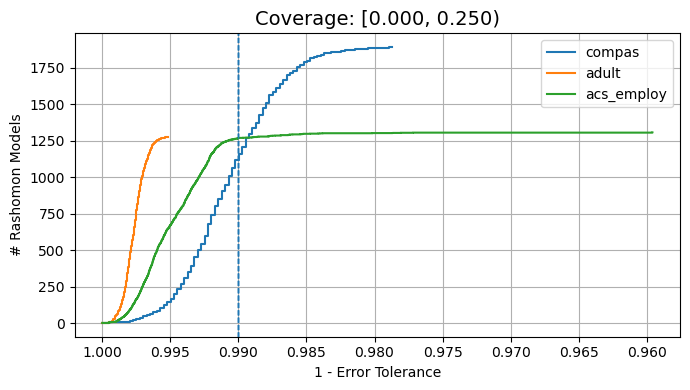

In [ ]:
method = 'HyRS'
Rashomon_Growth_one_quantiles (method, result_dir,quantile='q1', seed=0, n_quantiles=4, bins=None)

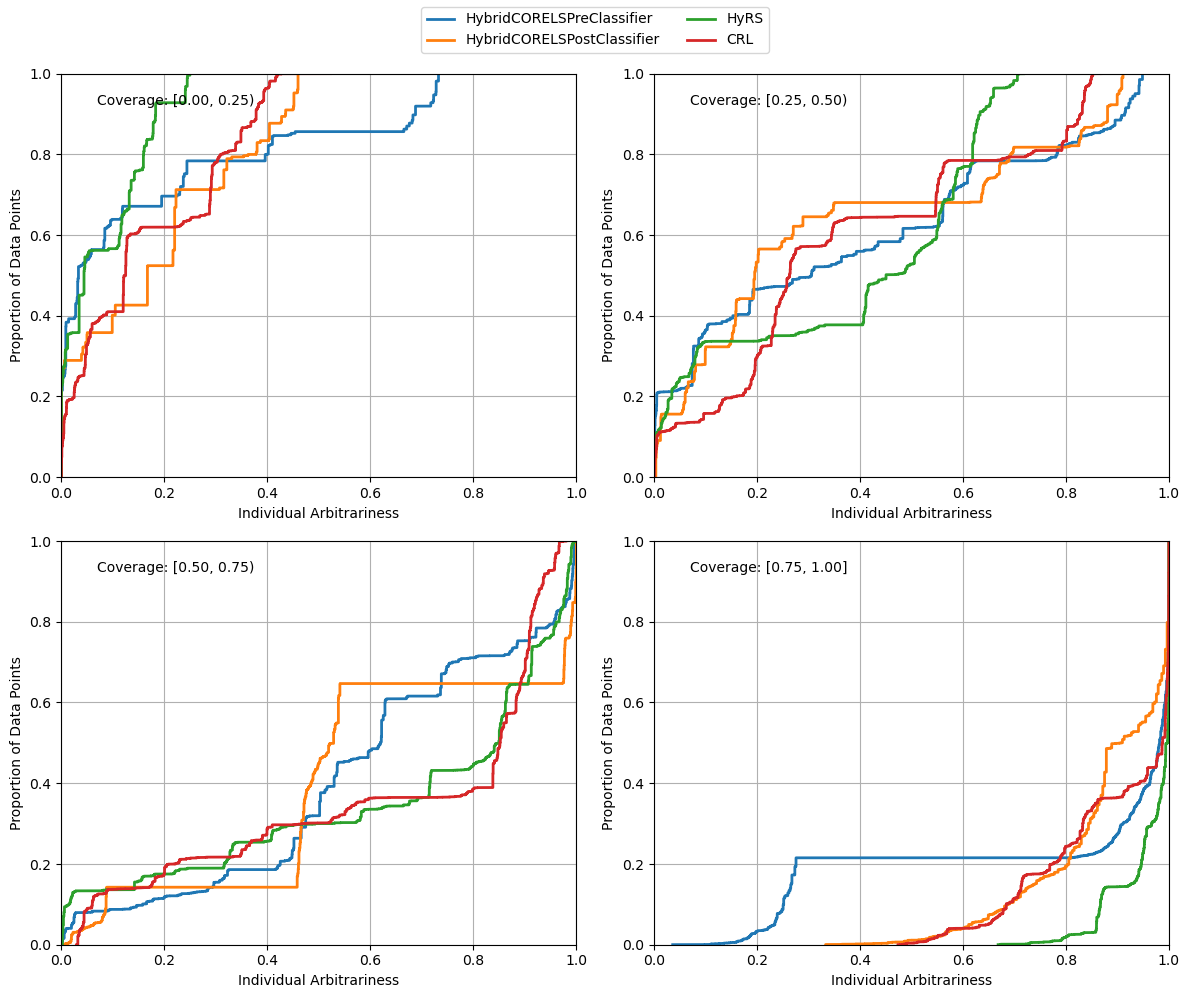

In [ ]:
"""This function generates a plot comparing the average individual arbitrariness 
across different methods for a given dataset. 
It computes the Rashomon sets for each method, 
calculates the average individual arbitrariness for models in each quantile of coverage rate, 
and plots the mean and standard deviation of the average individual arbitrariness across
    quantiles for each method on the same graph.

"""

methods = [
    'HybridCORELSPreClassifier',
    'HybridCORELSPostClassifier',
    'HyRS',
    'CRL'
]


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange',
    'HyRS': 'tab:green',
    'CRL': 'tab:red'
}

for m_idx, method in enumerate(methods):

    # --- compute Rashomon sets ---

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
    # --- compute arbitrariness ---
    for i, q in enumerate(epsilon_rashomon_per_quantile.keys()):
        ax = axes[i]

        pred_types_list = []
        for model in epsilon_rashomon_per_quantile[q]:
            pred_types_list.append(model[f'preds_types_{split}'])

        if len(pred_types_list) == 0:
            continue

        all_models_pred_type = np.column_stack(pred_types_list)
        arbitrariness = np.mean(all_models_pred_type, axis=1) #average of predcition type across Rashomon set
        # Sort values for empirical CDF
        x = np.sort(arbitrariness)
        y = np.arange(1, len(x) + 1) / len(x)

        ax.step(
            x,
            y,
            where='post',
            linewidth=2,
            color=color_map[method],
            label=method
        )
            
      

# -------------------------------
# Formatting per subplot
# -------------------------------
for i, ax in enumerate(axes):
    lower = quantiles[i]
    upper = quantiles[i+1]

    label = f"[{lower:.2f}, {upper:.2f})" if i < 3 else f"[{lower:.2f}, {upper:.2f}]"
    ax.set_xlabel("Individual Arbitrariness")
    ax.set_ylabel("Proportion of Data Points")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.text(
    0.07, 0.95,                      # position (relative to axes)
    f"Coverage: {label}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top'
    )

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

#fig.suptitle(f"{dataset_name.capitalize()} | Individual Arbitrariness", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = Path.cwd()/'plots'/'Arbit'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"CDF_Individual_arbitrariness_{Dataset_name}.png"
#plt.savefig(output_file, bbox_inches="tight")

plt.show()
plt.close()


In [ ]:
DATASETS

['compas', 'adult', 'acs_employ']

In [ ]:
epsilon


0.1

In [ ]:
DATASETS

['compas', 'adult', 'acs_employ']


HybridCORELSPre_Fair
  Q1: 0.098
  Q2: 0.114
  Q3: 0.294
  Q4: 0.040

HybridCORELSPost_Fair
  Q1: 0.098
  Q2: 0.000
  Q3: 0.326
  Q4: 0.000

HybridCORELSPre
  Q1: 0.098
  Q2: 0.159
  Q3: 0.388
  Q4: 0.234

HybridCORELSPost
  Q1: 0.098
  Q2: 0.038
  Q3: 0.349
  Q4: 0.008


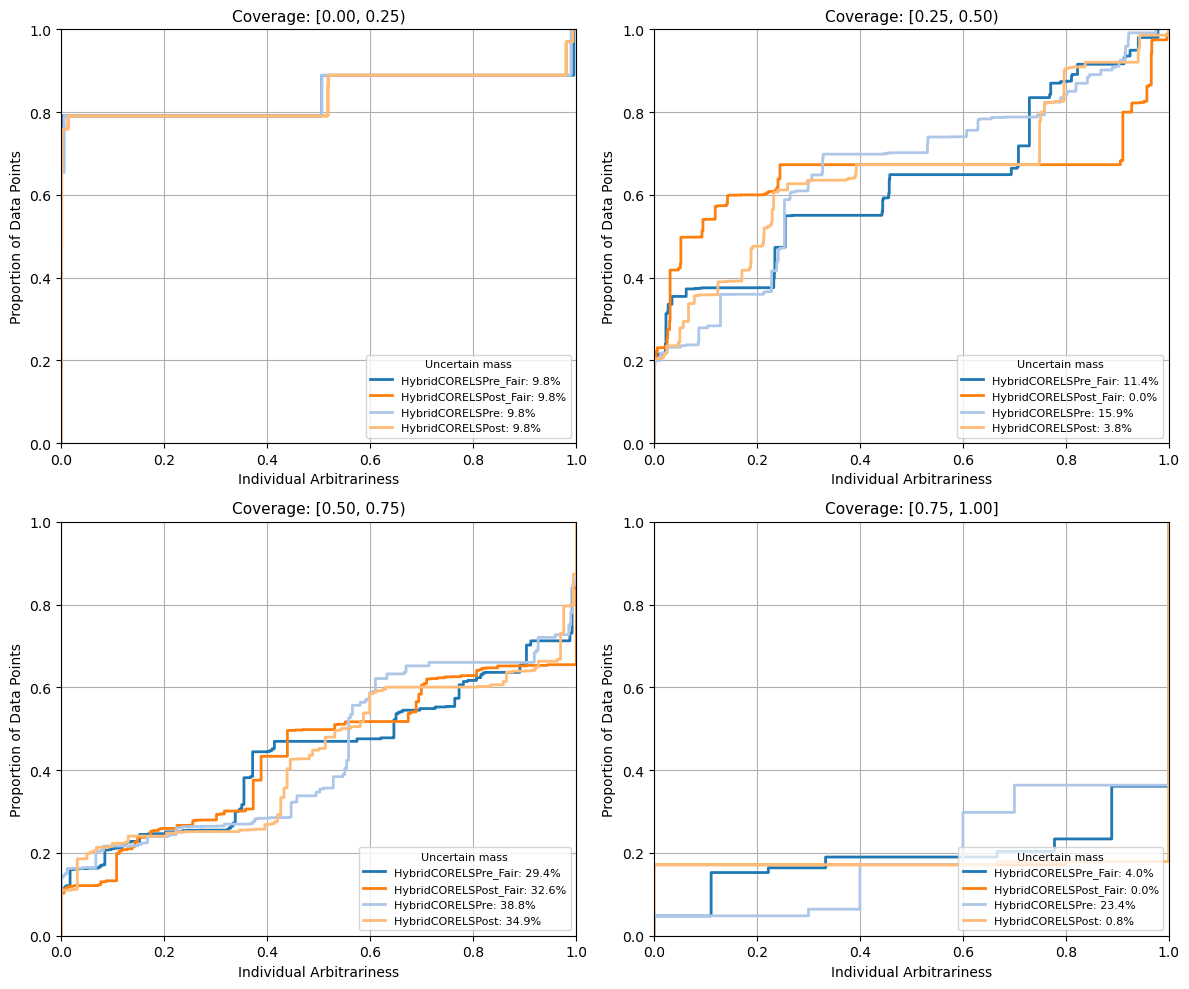

In [ ]:
epsilon = 0.01
demographic_group = 'Gender'
Dataset_name = 'acs_employ'

"""This function generates a plot comparing the average individual arbitrariness 
across different methods for a given dataset. 
It computes the Rashomon sets for each method, 
calculates the average individual arbitrariness for models in each quantile of coverage rate, 
and plots the mean and standard deviation of the average individual arbitrariness across
    quantiles for each method on the same graph.

"""



result_dir ={'HybridCORELSPre_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
            'HybridCORELSPost_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
            'HybridCORELSPre': Path.cwd()/"bootstrap_results",
            'HybridCORELSPost': Path.cwd()/"bootstrap_results"}
method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
            'HybridCORELSPost_Fair':'HybridCORELSPostClassifier',
            'HybridCORELSPre':'HybridCORELSPreClassifier',
            'HybridCORELSPost':'HybridCORELSPostClassifier'}

color_map = {
    'HybridCORELSPre_Fair': '#1f77b4',   # strong blue
    'HybridCORELSPost_Fair': '#ff7f0e',  # strong orange
    'HybridCORELSPre': '#aec7e8',             # light blue
    'HybridCORELSPost': '#ffbb78'             # light orange
    }

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
uncertain_results = {method: [] for method in method_match}
for meth_indx, j in enumerate(list(method_match.keys())):

    # --- compute Rashomon sets ---

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method_match[j], result_dir[j], seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
    # --- compute arbitrariness ---
    
    for i, q in enumerate(epsilon_rashomon_per_quantile.keys()):
        if not len(epsilon_rashomon_per_quantile[q]):
            continue
        ax = axes[i]

        pred_types_list = []
        for model in epsilon_rashomon_per_quantile[q]:
            pred_types_list.append(model[f'preds_types_{split}'])

        if len(pred_types_list) == 0:
            continue

        all_models_pred_type = np.column_stack(pred_types_list)
        arbitrariness = np.mean(all_models_pred_type, axis=1) #average of predcition type across Rashomon set
        uncertain_mass = np.mean((arbitrariness > 0.3) & (arbitrariness < 0.7))
        uncertain_results[j].append(uncertain_mass)
        x = np.sort(arbitrariness)
        y = np.arange(1, len(x) + 1) / len(x)

        ax.step(
            x,
            y,
            where='post',
            linewidth=2,
            color=color_map[j],
            label=f"{j}: {100 * uncertain_mass:.1f}%"
        )
#this is to reveal uncertain_results information
for method in method_match:
    print(f"\n{method}")
    for i, val in enumerate(uncertain_results[method]):
        print(f"  Q{i+1}: {val:.3f}")
# -------------------------------
# Formatting per subplot
# -------------------------------
for i, ax in enumerate(axes):
    lower = quantiles[i]
    upper = quantiles[i+1]

    label = f"[{lower:.2f}, {upper:.2f})" if i < 3 else f"[{lower:.2f}, {upper:.2f}]"
    ax.set_title(f"Coverage: {label}", fontsize=11)
    ax.set_xlabel("Individual Arbitrariness")
    ax.set_ylabel("Proportion of Data Points")
    ax.grid(True)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # ax.text(
    # 0.07, 0.95,                      # position (relative to axes)
    # f"Coverage: {label}",
    # transform=ax.transAxes,
    # fontsize=10,
    # verticalalignment='top'
    # )
    ax.legend(
        loc="lower right",
        fontsize=8,
        frameon=True,
        title="Uncertain mass",
        title_fontsize=8
    )

# # Shared legend
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=2)

#fig.suptitle(f"{dataset_name.capitalize()} | Individual Arbitrariness", fontsize=14)

plt.tight_layout()

output_dir = Path.cwd()/'plots'/'Arbit'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"CDF_Fair_Individual_arbitrariness_{Dataset_name}_{demographic_group}.png"
#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()

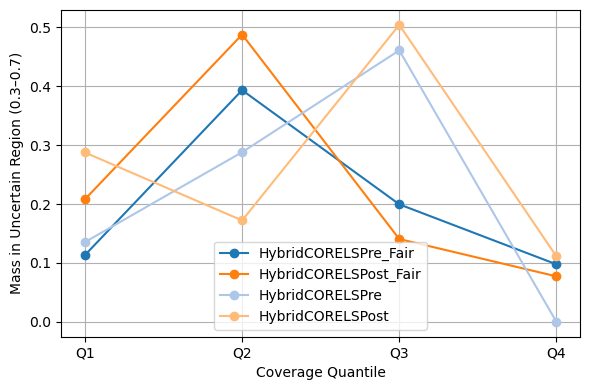

In [ ]:
quantile_labels = [f"Q{i+1}" for i in range(n_quantiles)]

plt.figure(figsize=(6,4))

for method in method_match:
    plt.plot(
        quantile_labels,
        uncertain_results[method],
        marker='o',
        label=method,
        color=color_map[method]
    )

plt.ylabel("Mass in Uncertain Region (0.3–0.7)")
plt.xlabel("Coverage Quantile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pairs = [
    ("HybridCORELSPre", "HybridCORELSPre_Fair"),
    ("HybridCORELSPost", "HybridCORELSPost_Fair")
]

for base, fair in pairs:
    print(f"\n{base} vs {fair}")
    for i in range(n_quantiles):
        diff = uncertain_results[fair][i] - uncertain_results[base][i]
        print(f"  Q{i+1}: Δ = {diff:.3f}")


HybridCORELSPre vs HybridCORELSPre_Fair
  Q1: Δ = 0.034
  Q2: Δ = 0.057
  Q3: Δ = 0.288
  Q4: Δ = 0.066

HybridCORELSPost vs HybridCORELSPost_Fair
  Q1: Δ = 0.165
  Q2: Δ = -0.391
  Q3: Δ = 0.398
  Q4: Δ = 0.087


In [ ]:
result_dir = Path.cwd()/"bootstrap_results"

In [ ]:
epsilon = 0.10

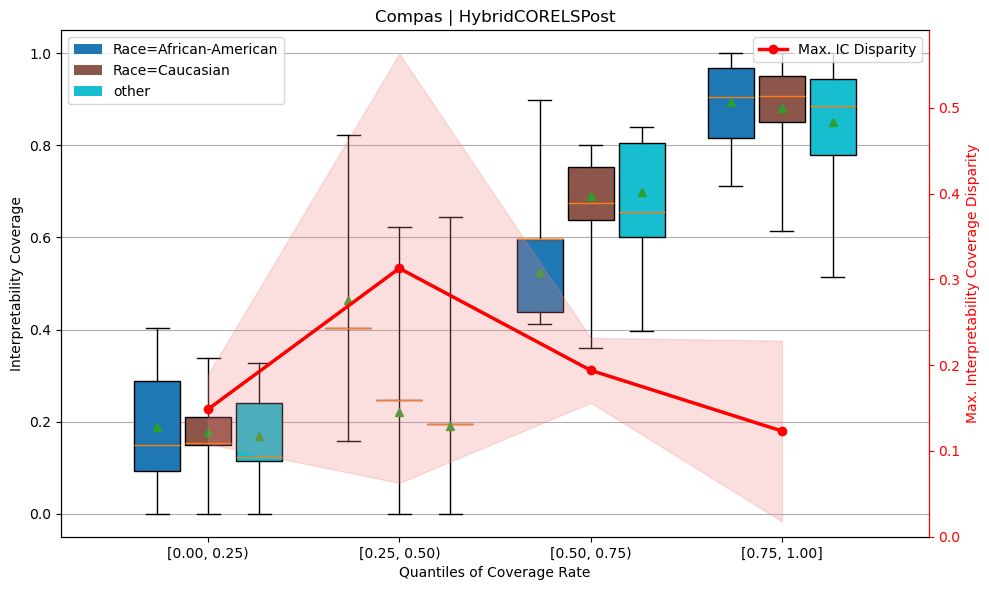

In [ ]:
seed = 0 
np.random.seed(seed)

train_proportion = 0.8

my_data = Dataset.from_csv(
    Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
    Dataset_name
)
my_data.pre_process()

X, y, features, prediction = my_data.get_data_norulemining(
    {"train": train_proportion, "test": 1-train_proportion},
    random_state_param=seed
)


conditions = my_data.demographicGroup(summarized=True)[demographic_group]
eval = Evaluation(X[split], features, conditions)



# --- compute Rashomon Set ---
epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
)

# -------------------------------
# Compute statistics
# -------------------------------
All_all = {cond: [] for cond in conditions}
mean_icf_disparity = []
std_icf_disparity = []
for q in epsilon_rashomon_per_quantile.keys():

    all_icf = {cond: [] for cond in conditions}
    all_icf_disparity = []

    for model in epsilon_rashomon_per_quantile[q]:
        ICF = eval.compute_fairness(model[f'preds_types_{split}'])
        ICF_disparity = eval.compute_ICF_disparity(ICF)

        all_icf_disparity.append(ICF_disparity['over_all_groups'])

        for cond in conditions:
            all_icf[cond].append(ICF[cond])

    mean_icf_disparity.append(np.mean(all_icf_disparity))
    std_icf_disparity.append(np.std(all_icf_disparity))

    for cond in conditions:
        All_all[cond].append(all_icf[cond])

# -------------------------------
# PLOTTING (UPDATED FOR ANY #GROUPS)
# -------------------------------
    
# Using two y axes due to scale difference
fig, ax1 = plt.subplots(figsize=(10, 6))

num_groups = len(conditions)
num_quantiles = len(epsilon_rashomon_per_quantile.keys())

base_positions = np.arange(1, num_quantiles + 1)

# dynamic spacing
total_width = 0.8
width = total_width / num_groups

# dynamic colors
colors = plt.cm.tab10(np.linspace(0, 1, num_groups))

# --- BOX PLOTS (left axis) ---
for i, cond in enumerate(conditions):

    # center all groups
    positions = base_positions + (i - (num_groups - 1)/2) * width

    box = ax1.boxplot(
        All_all[cond],
        positions=positions,
        widths=width * 0.9,
        showmeans=True,
        whis=[0, 100],
        patch_artist=True
    )

    for patch in box['boxes']:
        patch.set_facecolor(colors[i])

ax1.set_ylabel('Interpretability Coverage')
ax1.set_xlabel(f'Quantiles of Coverage Rate')

# --- SECOND AXIS (right) ---

ax2 = ax1.twinx()

line_color = "red"
shade_color = "lightcoral"

ax2.plot(
    base_positions,
    mean_icf_disparity,
    color=line_color,
    marker='o',
    linewidth=2.5,
    label='Max. IC Disparity'
)

ax2.fill_between(
    base_positions,
    np.array(mean_icf_disparity) - np.array(std_icf_disparity),
    np.array(mean_icf_disparity) + np.array(std_icf_disparity),
    color=shade_color,
    alpha=0.25
)

ax2.set_ylabel(
    'Max. Interpretability Coverage Disparity',
    color=line_color
)

# make right axis red
ax2.tick_params(axis='y', colors=line_color)
ax2.spines['right'].set_color(line_color)
ax2.yaxis.label.set_color(line_color)
ax2.set_ylim(bottom=0)
# disparity legend (line)
ax2.legend(loc='upper right')



# boxplot legend (groups)
legend_elements = [
    Patch(facecolor=colors[i], label=cond)
    for i, cond in enumerate(conditions)
]

ax1.legend(handles=legend_elements, loc='upper left')


# --- formatting ---
plt.title(f'{Dataset_name.capitalize()} | {method}')
ax1.set_xticks(base_positions)

#to generate quantiles range labels
labels = []
for i in range(len(quantiles) - 1):
    if i < len(quantiles) - 2:
        labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
    else:
        labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")

ax1.set_xticklabels(labels)

ax1.grid(axis='y')
plt.tight_layout()
# # --- save ---
output_dir = Path.cwd()/'plots'/'ICF'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"Comp_ICF_2axis{Dataset_name}_{method}_{demographic_group}_{epsilon}.png"
#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()


In [ ]:
DATASETS

['compas', 'adult', 'acs_employ']

In [ ]:
Dataset_name = 'compas'

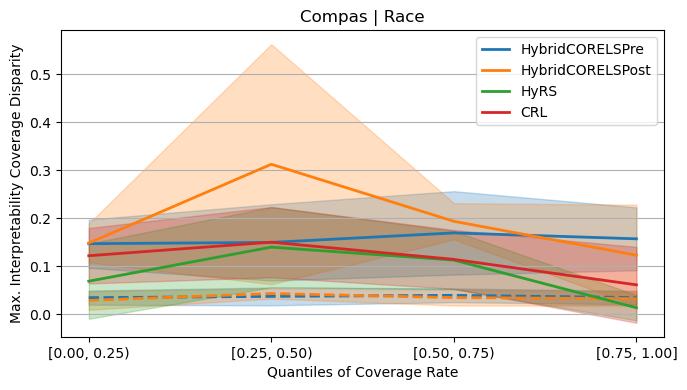

In [ ]:
epsilon = 0.10


result_dir ={'HybridCORELSPre_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
            'HybridCORELSPost_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
            'HybridCORELSPre': Path.cwd()/"bootstrap_results",
            'HybridCORELSPost': Path.cwd()/"bootstrap_results",
            'HyRS':Path.cwd()/"bootstrap_results",
            'CRL':Path.cwd()/"bootstrap_results" }
method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                'HybridCORELSPre':'HybridCORELSPreClassifier',
                'HybridCORELSPost_Fair':'HybridCORELSPostClassifier',
            'HybridCORELSPost':'HybridCORELSPostClassifier',
            'HyRS': 'HyRS',
            'CRL': 'CRL'}
seed = 0 
np.random.seed(seed)

train_proportion = 0.8

my_data = Dataset.from_csv(
    Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
    Dataset_name
)
my_data.pre_process()

X, y, features, prediction = my_data.get_data_norulemining(
    {"train": train_proportion, "test": 1-train_proportion},
    random_state_param=seed)
color_map = {
'HybridCORELSPreClassifier': 'tab:blue',
'HybridCORELSPostClassifier': 'tab:orange',
'HyRS': 'tab:green',
'CRL': 'tab:red',

}


plt.figure(figsize=(7, 4))
for method in method_match:
    # -------------------------------
    # Collect Rashomon models
    # -------------------------------

    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method_match[method], result_dir = result_dir[method], seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )
        # -------------------------------
    # Compute statistics
    # -------------------------------
    
    conditions = my_data.demographicGroup(summarized=True)[demographic_group]

    eval = Evaluation(X[split], features, conditions)


    mean_icf_disparity = []
    std_icf_disparity = []

    for q in epsilon_rashomon_per_quantile.keys():

        all_icf_disparity = []

        for model in epsilon_rashomon_per_quantile[q]:
            ICF = eval.compute_fairness(model[f'preds_types_{split}'])
            ICF_disparity = eval.compute_ICF_disparity(ICF)

            all_icf_disparity.append(ICF_disparity['over_all_groups'])


        mean_icf_disparity.append(np.mean(all_icf_disparity))
        std_icf_disparity.append(np.std(all_icf_disparity))

    x_pos = np.arange(len(epsilon_rashomon_per_quantile))
    linestyle = '--' if "Fair" in method else '-'
    plt.plot(
        x_pos,
        mean_icf_disparity,
        label = f'{method}' if "Fair" not in method else None,
        linewidth=2, color = color_map [method_match[method]], linestyle = linestyle
    )

    plt.fill_between(
        x_pos,
        np.array(mean_icf_disparity) - np.array(std_icf_disparity),
        np.array(mean_icf_disparity) + np.array(std_icf_disparity),
        color= color_map [method_match[method]],
        alpha=0.25
    )


plt.legend() 

plt.xlabel(f'Quantiles of Coverage Rate')
plt.ylabel('Max. Interpretability Coverage Disparity')
plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

labels = []
for i in range(len(quantiles) - 1):
    if i < len(quantiles) - 2:
        labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
    else:
        labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")

plt.xticks(x_pos, labels)
plt.grid(axis='y')
plt.tight_layout()
# --- save ---
output_dir = Path.cwd()/'plots'/'ICF'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"Max_Delta_ICF{Dataset_name}_{demographic_group}_{epsilon}.png"

#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()


In [ ]:
Dataset_name = 'acs_employ'
my_data = Dataset.from_csv(
    Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
    Dataset_name
)

In [ ]:
DATASETS

['compas', 'adult', 'acs_employ']

In [ ]:
my_data.X.shape

(208358, 300)

In [ ]:
1001*10

10010

In [ ]:
ESTIMATORS

['HybridCORELSPreClassifier', 'HybridCORELSPostClassifier', 'HyRS', 'CRL']

In [ ]:
def max_delta_ICF_all_methods_box(Dataset_name,seed, result_dir, epsilon,split, demographic_group, n_quantiles, bins):
    """This function generates a plot comparing the maximum Interpretability Coverage Disparity 
    across different methods for a given dataset and demographic group. 
    It computes the Rashomon sets for each method, 
    calculates the ICF disparity for models in each quantile of coverage rate, 
    and plots the mean and standard deviation of the maximum ICF disparity across
      quantiles for each method on the same graph.

    """

    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange',
    'HyRS': 'tab:green',
    'CRL': 'tab:red'
    }
    plt.figure(figsize=(7, 4))
    for i,method in enumerate(ESTIMATORS):
        # -------------------------------
        # Collect Rashomon models
        # -------------------------------

        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
        Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
        )
            # -------------------------------
        # Compute statistics
        # -------------------------------
        
        conditions = my_data.demographicGroup(summarized=True)[demographic_group]

        eval = Evaluation(X[split], features, conditions)


    
        all_icf_disparity_per_quantile = []

        for q in epsilon_rashomon_per_quantile.keys():

            all_icf_disparity = []

            for model in epsilon_rashomon_per_quantile[q]:
                ICF = eval.compute_fairness(model[f'preds_types_{split}'])
                ICF_disparity = eval.compute_ICF_disparity(ICF)

                all_icf_disparity.append(ICF_disparity['over_all_groups'])

            all_icf_disparity_per_quantile.append(all_icf_disparity)
          


        num_methods = len(ESTIMATORS)
        num_quantiles = len(epsilon_rashomon_per_quantile.keys())

        base_positions = np.arange(1, num_quantiles + 1)

        # dynamic spacing
        total_width = 0.8
        width = total_width / num_methods


        # --- BOX PLOTS ---
        # center all groups
        positions = base_positions + (i - (num_methods - 1)/2) * width

        box = plt.boxplot(
            all_icf_disparity_per_quantile,
            positions=positions,
            widths=width * 0.9,
            showmeans=True,
            whis=[0, 100],
            patch_artist=True
        )

        for patch in box['boxes']:
            patch.set_facecolor(color_map[method])
            patch.set_alpha(0.7)



    plt.legend()

    plt.xlabel(f'Quantiles of Coverage Rate')
    plt.ylabel('Max. Interpretability Coverage Disparity')
    #plt.title(f'{Dataset_name.capitalize()}')

    labels = []
    for i in range(len(quantiles) - 1):
        if i < len(quantiles) - 2:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
        else:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
     # --- LEGENDS ---
    # boxplot legend (groups)
    legend_elements = [
        Patch(facecolor=color_map[method], label=method)
        for i, method in enumerate(ESTIMATORS)
    ]

    plt.legend(handles=legend_elements, loc='upper left')
    plt.xticks(base_positions, labels)
    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'ICF'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Max_Delta_ICF{Dataset_name}_{demographic_group}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
result_dir = Path.cwd()/"bootstrap_results"

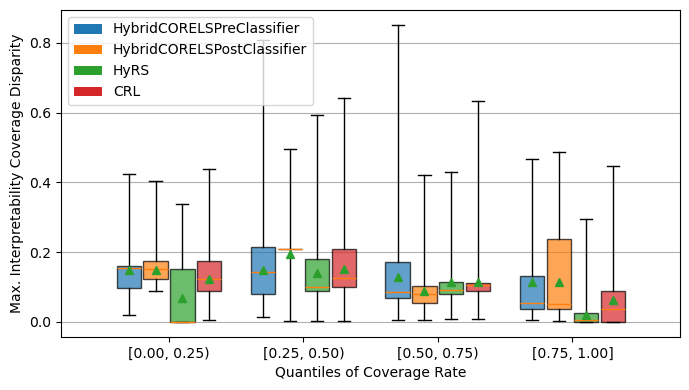

In [ ]:
max_delta_ICF_all_methods(Dataset_name='compas',seed=0, result_dir=result_dir, epsilon=0.05,split='train', demographic_group='Race', n_quantiles=4, bins=None)

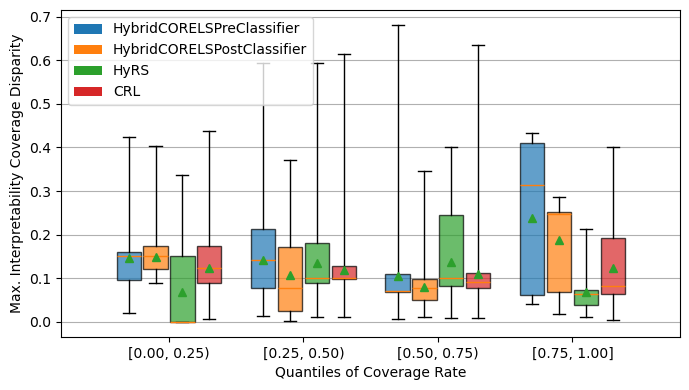

In [ ]:
max_delta_ICF_all_methods(Dataset_name='compas',seed=0, result_dir=result_dir, epsilon=0.01,split='train', demographic_group='Race', n_quantiles=4, bins=None)

In [ ]:
(result_dir/'Mitigation_results'/'MGender').exists()

True

In [ ]:
result_dir = Path('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper')

In [ ]:
result_dir

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper')

In [ ]:
epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir = result_dir/'Mitigation_results'/'MGender', seed=seed, n_quantiles=1, bins=bins, epsilon=0.01, max_cov = 0.01
    )

In [ ]:
epsilon_rashomon_per_quantile

{'q1': [{'test-train-split-seed': 0,
   'round_number': 0,
   'bootstrap_id': 0,
   'rules': (133, 63, 89, 104),
   'preds_train': array([1, 0, 0, ..., 0, 1, 0], shape=(5771,), dtype=uint8),
   'preds_types_train': array([0, 1, 1, ..., 0, 0, 1], shape=(5771,), dtype=uint8),
   'preds_test': array([1, 1, 1, ..., 0, 1, 1], shape=(1443,), dtype=uint8),
   'preds_types_test': array([0, 0, 1, ..., 1, 0, 1], shape=(1443,), dtype=uint8),
   'acc_train': 0.6896551724137931,
   'acc_test': 0.6777546777546778,
   'coverage_rate_train': 0.7005718246404437,
   'coverage_rate_test': 0.717948717948718,
   'status': 'time_out'},
  {'test-train-split-seed': 0,
   'round_number': 9,
   'bootstrap_id': 0,
   'rules': (102, 104),
   'preds_train': array([1, 0, 0, ..., 0, 1, 0], shape=(5771,), dtype=uint8),
   'preds_types_train': array([0, 0, 1, ..., 0, 0, 0], shape=(5771,), dtype=uint8),
   'preds_test': array([1, 1, 1, ..., 0, 1, 1], shape=(1443,), dtype=uint8),
   'preds_types_test': array([0, 0, 1, .

In [ ]:

def generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=None):

    # -------------------------------
    # Load all models for each dataset and method and seed
    # -------------------------------
    all_models = []
    for f in result_dir.iterdir():
        if max_cov:
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name and f.name.endswith(f"_{max_cov:.2f}_.pkl"):
              
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)
        else:
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name :
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)

    # -------------------------------
    # Define bins (GLOBAL)
    # -------------------------------
    if bins is not None:
        quantiles = np.array(bins)
    else:
        quantiles = np.linspace(0, 1, n_quantiles + 1)

    n_quantiles = len(quantiles) - 1

    #find all the uniqe models first
    unique_preds = set()
    unique_models = []
   
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy()) #generate all unique models first and then assign them to quantiles

    unique_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # -------------------------------
    # Assign models to bins
    # -------------------------------
    for model in unique_models:
        val = model['coverage_rate_train']

        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]

            if (i < n_quantiles - 1 and lower <= val < upper) or \
                (i == n_quantiles - 1 and lower <= val <= upper):
                unique_models_per_quantiles[f"q{i+1}"].append(model)
                break
        # Print summary
    # for key, models in unique_models_per_quantiles.items():
    #     if len(models) == 0:
    #         continue
    #     coverages = [m['coverage_rate_train'] for m in models]
    #     accuracies = [m['acc_train'] for m in models]

    #     print(f"{key}:")
    #     print(f"  number of models: {len(models)}")
    #     print(f"  mean coverage: {np.mean(coverages):.4f}")
    #     print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    # Now apply epsilon filter to find the epsilon Rashomon set for each quantile
    epsilon_rashomon_per_quantile = {f"q{i+1}": [] for i in range(n_quantiles)}
    for q in unique_models_per_quantiles.keys():
        max_acc = max([i['acc_train'] for i in unique_models_per_quantiles[q]])
        best_model = max(unique_models_per_quantiles[q], key=lambda x: x['acc_train'])
        for i in unique_models_per_quantiles[q]:
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon_per_quantile[q].append(i.copy())


    return epsilon_rashomon_per_quantile, unique_models_per_quantiles, quantiles



In [ ]:
Dataset_name

'compas'

In [ ]:
result_dir

{'HybridCORELSPre_Fair': PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender'),
 'HybridCORELSPost_Fair': PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender'),
 'HybridCORELSPre': PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/bootstrap_results'),
 'HybridCORELSPost': PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/bootstrap_results')}

In [ ]:
result_dir_n = Path.cwd()/'Mitigation_results'/'MGender'

In [ ]:
Dataset_name = 'compas'
method = 'HybridCORELSPostClassifier'
max_cov = 0.10
all_models = []
if max_cov:
    result_dir = Path.cwd()/'Mitigation_results'/'MGender'
    for f in (result_dir).iterdir():
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name and f.name.endswith(f"_{max_cov}_.pkl"):
                print(f.name)
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)
else:
    result_dir = Path.cwd()/'Mitigation_results'/'Gender' #this is only for default 0.05
    for f in (result_dir).iterdir():
        if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name :
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)

In [ ]:
max_cov = '0.10'

In [ ]:
max_cov

0.1

In [ ]:
max_cov = 0.10
result_dir = Path.cwd()/'Mitigation_results'/'MGender'
for f in (result_dir).iterdir():
    if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name  and f.name.endswith(f"_{max_cov:.2f}_.pkl") :
        print(f.name)

compas_HybridCORELSPostClassifier_seed0_round9_param0.7_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round4_param0.7_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round0_param0.3_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round3_param0.8_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round1_param0.6_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round6_param0.9_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round5_param0.2_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round8_param0.2_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round7_param0.1_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round3_param0.5_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round6_param0.4_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round8_param0.4_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round5_param0.4_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round4_param0.1_0.10_.pkl
compas_HybridCORELSPostClassifier_seed0_round9_param0.1_0.10_.pkl
compas_Hyb

In [ ]:
np.min([i['coverage_rate_train'] for i in all_models])

np.float64(0.09894299081614971)

1086
917


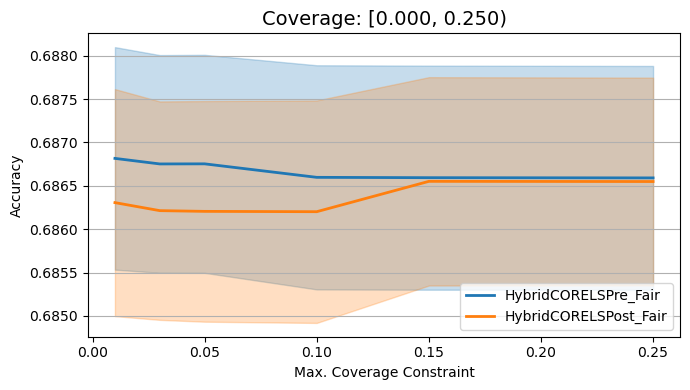

In [ ]:
Dataset_name = 'compas'
demographic_group = 'Gender'
quantile = 'q1' #name of given quantile  ['q1', 'q2', 'q3', 'q4']
n_quantiles = 4
all_max_cov = [0.01, 0.03, 0.05, 0.10, 0.15, 0.25]

#[0.01, 0.03, 0.10, 0.15, 0.25]
result_dir_n = Path.cwd()/'Mitigation_results'/'MGender'

plt.figure(figsize=(7, 4))
color_map = {
'HybridCORELSPre_Fair': 'tab:blue',
'HybridCORELSPost_Fair': 'tab:orange'}

method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                'HybridCORELSPost_Fair':'HybridCORELSPostClassifier'}
for method in method_match.keys():
    
    mean_acc = []
    std_acc = []
    for m in all_max_cov:
        max_cov = m
        if m == 0.05:
            max_cov = None
            result_dir = Path.cwd()/'Mitigation_results'/'Gender'
        else :
            result_dir = Path.cwd()/'Mitigation_results'/'MGender'
        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
            Dataset_name, method_match[method], result_dir = result_dir, seed=seed, n_quantiles=n_quantiles, bins=None, epsilon=0.01, max_cov = max_cov)
        n_q = len(epsilon_rashomon_per_quantile)
        q = quantile 
    
        mean_acc.append(np.average([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]))
        std_acc.append(np.std([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]))
    print(len(epsilon_rashomon_per_quantile[q]))
    plt.plot(
        all_max_cov,
        mean_acc,
        label = f'{method}',
        linewidth=2, color = color_map[method]
    )

    plt.fill_between(
        all_max_cov,
        np.array(mean_acc) - np.array(std_acc),
        np.array(mean_acc) + np.array(std_acc),
        color= color_map[method],
        alpha=0.25
    )

i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
label = (
        f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
        if i < n_q - 1
        else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
# Global title
plt.title(f"Coverage: {label}", fontsize=14)


plt.legend()
plt.xlabel(f'Max. Coverage Constraint')
plt.ylabel('Accuracy')
#plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

plt.grid(axis='y')
plt.tight_layout()
# --- save ---
output_dir = Path.cwd()/'plots'/'Fair'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"Acc_maxcoverage_{Dataset_name}_{demographic_group}.png"
#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()
                

In [ ]:
def Acc_Max_Coverage_one_quantile (Dataset_name,seed, epsilon, demographic_group, n_quantiles,all_max_cov, quantile ,bins=None):

    #name of given quantile  ['q1', 'q2', 'q3', 'q4']

    #all_max_cov = [0.01, 0.05]
    #[0.01, 0.03, 0.10, 0.15, 0.25]
    result_dir_n = result_dir/'Mitigation_results'/'MGender' #MGenderincludes all mitigated experiments for all max coverages 

    plt.figure(figsize=(7, 4))
    color_map = {
    'HybridCORELSPre_Fair': 'tab:blue',
    'HybridCORELSPost_Fair': 'tab:orange'}

    method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                    'HybridCORELSPost_Fair':'HybridCORELSPostClassifier'}
    for method in method_match.keys():
        
        mean_acc = []
        std_acc = []
        for m in all_max_cov:
            max_cov = m
            if m == 0.05:
                max_cov = None # names of the files are different for 0.05 (default) max_cov
            epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
                Dataset_name, method_match[method], result_dir = result_dir_n, seed=seed, n_quantiles=n_quantiles, bins=None, epsilon=epsilon, max_cov = max_cov)
            n_q = len(epsilon_rashomon_per_quantile)
            q = quantile 
        
            mean_acc.append(np.average([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]))
            std_acc.append(np.std([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]))

        plt.plot(
            all_max_cov,
            mean_acc,
            label = f'{method}',
            linewidth=2, color = color_map[method]
        )

        plt.fill_between(
            all_max_cov,
            np.array(mean_acc) - np.array(std_acc),
            np.array(mean_acc) + np.array(std_acc),
            color= color_map[method],
            alpha=0.25
        )

    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)


    plt.legend()
    plt.xlabel(f'Max. Coverage Constraint')
    plt.ylabel('Accuracy')
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Fair'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Acc_maxcoverage_{Dataset_name}_{demographic_group}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()
                

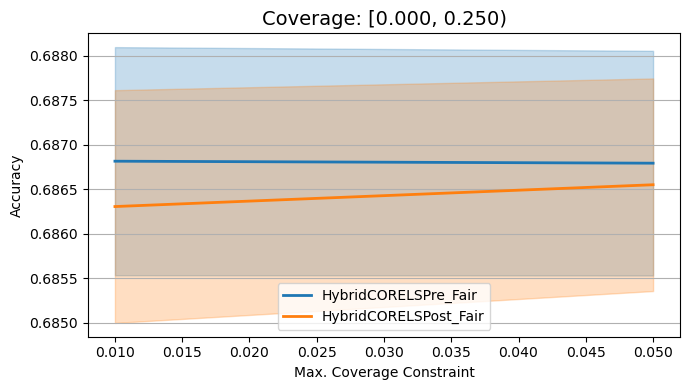

In [ ]:
Dataset_name = 'compas'

Acc_Max_Coverage_one_quantile(Dataset_name='compas',seed=0, epsilon=0.01, demographic_group='Gender', n_quantiles=4,all_max_cov=[0.01,0.05], quantile='q1' ,bins=None)

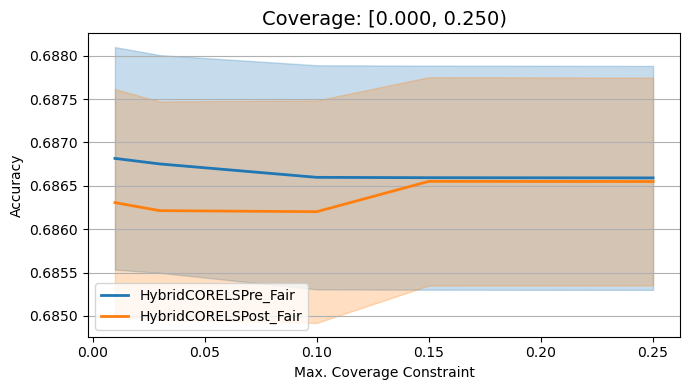

In [ ]:
#name of given quantile  ['q1', 'q2', 'q3', 'q4']

all_max_cov = [0.01, 0.03, 0.10, 0.15, 0.25]
result_dir_n = Path.cwd()/'Mitigation_results'/'MGender' #MGenderincludes all mitigated experiments for all max coverages 

plt.figure(figsize=(7, 4))
color_map = {
'HybridCORELSPre_Fair': 'tab:blue',
'HybridCORELSPost_Fair': 'tab:orange'}

method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                'HybridCORELSPost_Fair':'HybridCORELSPostClassifier'}
for method in method_match.keys():
    
    mean_acc = []
    std_acc = []
    for m in all_max_cov:
        max_cov = m
        if m == 0.05:
            max_cov = None # names of the files are different for 0.05 (default) max_cov
            result_dir_n = Path.cwd()/'Mitigation_results'/'Gender'
        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
            Dataset_name, method_match[method], result_dir = result_dir_n, seed=seed, n_quantiles=n_quantiles, bins=None, epsilon=epsilon, max_cov = max_cov)
        n_q = len(epsilon_rashomon_per_quantile)
        q = quantile 
    
        mean_acc.append(np.average([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[q]]))
        std_acc.append(np.std([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[q]]))

    plt.plot(
        all_max_cov,
        mean_acc,
        label = f'{method}',
        linewidth=2, color = color_map[method]
    )

    plt.fill_between(
        all_max_cov,
        np.array(mean_acc) - np.array(std_acc),
        np.array(mean_acc) + np.array(std_acc),
        color= color_map[method],
        alpha=0.25
    )

i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
label = (
        f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
        if i < n_q - 1
        else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
# Global title
plt.title(f"Coverage: {label}", fontsize=14)


plt.legend()
plt.xlabel(f'Max. Coverage Constraint')
plt.ylabel('Accuracy')
#plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

plt.grid(axis='y')
plt.tight_layout()
# --- save ---
output_dir = Path.cwd()/'plots'/'Fair'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"Acc_maxcoverage_{Dataset_name}_{demographic_group}_{quantile}.png"
#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:

#name of given quantile  ['q1', 'q2', 'q3', 'q4']
quantile = 'q1'
n_quantiles =4
#all_max_cov = [0.01, 0.03, 0.10, 0.15, 0.25]
result_dir_n = Path.cwd()/'Mitigation_results'/'MGender' #MGenderincludes all mitigated experiments for all max coverages 

plt.figure(figsize=(7, 4))
color_map = {
'HybridCORELSPre_Fair': 'tab:blue',
'HybridCORELSPost_Fair': 'tab:orange'}

method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                'HybridCORELSPost_Fair':'HybridCORELSPostClassifier'}
for method in ['HybridCORELSPost_Fair']:
    
    mean_acc = []
    std_acc = []
    for m in [0.01,0.03, 0.05]:
        max_cov = m
        print(max_cov)
        if m == 0.05:
                # names of the files are different for 0.05 (default) max_cov
            result_dir_n = Path.cwd()/'Mitigation_results'/'Gender'
            max_cov= None
        print(result_dir_n)
        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
            Dataset_name = Dataset_name, method = method_match[method], result_dir = result_dir_n, seed=seed, n_quantiles=n_quantiles, bins=None, epsilon=epsilon, max_cov = max_cov)
        n_q = len(epsilon_rashomon_per_quantile)
        q = quantile 
    
        mean_acc.append(np.min([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[q]]))
        std_acc.append(np.std([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[q]]))
        print(len(epsilon_rashomon_per_quantile[q]))
        print(mean_acc, std_acc)
#     plt.plot(
#         all_max_cov,
#         mean_acc,
#         label = f'{method}',
#         linewidth=2, color = color_map[method]
#     )

#     plt.fill_between(
#         all_max_cov,
#         np.array(mean_acc) - np.array(std_acc),
#         np.array(mean_acc) + np.array(std_acc),
#         color= color_map[method],
#         alpha=0.25
#     )

# i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
# label = (
#         f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
#         if i < n_q - 1
#         else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
# # Global title
# plt.title(f"Coverage: {label}", fontsize=14)


# plt.legend()
# plt.xlabel(f'Max. Coverage Constraint')
# plt.ylabel('Accuracy')
# #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

# plt.grid(axis='y')
# plt.tight_layout()
# # --- save ---
# output_dir = Path.cwd()/'plots'/'Fair'
# output_dir.mkdir(exist_ok=True)

# output_file = output_dir / f"Acc_maxcoverage_{Dataset_name}_{demographic_group}_{quantile}.png"
# #plt.savefig(output_file, bbox_inches="tight")
# plt.show()
# plt.close()

0.01
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/MGender
403
[np.float64(0.6844567665915786)] [np.float64(0.0013084009082125988)]
0.03
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/MGender
786
[np.float64(0.6844567665915786), np.float64(0.6844567665915786)] [np.float64(0.0013084009082125988), np.float64(0.0012588597834312318)]
0.05
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender
940
[np.float64(0.6844567665915786), np.float64(0.6844567665915786), np.float64(0.6844567665915786)] [np.float64(0.0013084009082125988), np.float64(0.0012588597834312318), np.float64(0.0012717039482660253)]


<Figure size 700x400 with 0 Axes>

In [ ]:
all_max_cov = [0.01, 0.03,0.05, 0.10, 0.15, 0.25]

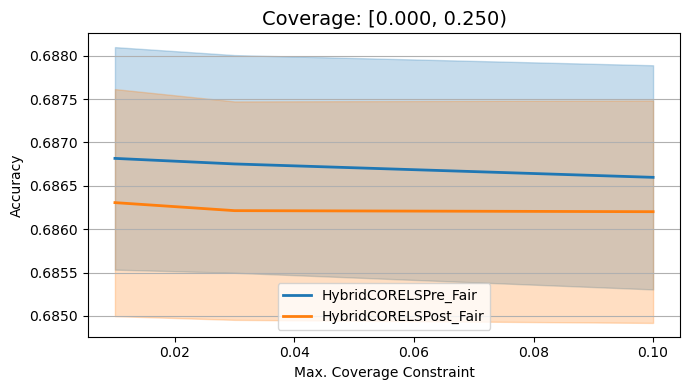

In [ ]:
Acc_Max_Coverage_one_quantile(Dataset_name=Dataset_name,seed=seed, epsilon=epsilon,split = split,\
                                  demographic_group=demographic_group, n_quantiles=4,all_max_cov=[0.01,0.03, 0.10], quantile='q1' ,bins=None)

In [ ]:
all_max_cov = [0.01, 0.03, 0.1, 0.15, 0.25]

In [ ]:
all_max_cov

[0.01, 0.03, 0.1, 0.15, 0.25]

In [ ]:
method_match[method]

KeyError: 'HybridCORELSPostClassifier'

In [ ]:
Dataset_name = 'compas'
method = 'HybridCORELSPostClassifier'
max_cov = None
result_dir = Path.cwd()/'Mitigation_results'/'Gender'
all_models = []
for f in result_dir.iterdir():
    if max_cov:
        if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name and f.name.endswith(f"_{max_cov:.2f}_.pkl"):
            
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)
    else:
        
        if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name :
            print(f)
            with open(f, "rb") as file:
                one_round = pickle.load(file)
                all_models.extend(one_round)


/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round9_param0.8.pkl
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round9_param0.9.pkl
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round9_param0.95.pkl
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round8_param0.9.pkl
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round8_param0.8.pkl
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/Gender/compas_HybridCORELSPostClassifier_seed0_round6_param0.3.pkl
/Users/ziba/programming/opt

In [ ]:
len(all_models)

10100

In [ ]:
def generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=None):

    # -------------------------------
    # Load all models for each dataset and method and seed
    # -------------------------------
    all_models = []
    for f in result_dir.iterdir():
        if max_cov:
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name and f.name.endswith(f"_{max_cov:.2f}_.pkl"):
              
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)
        else:
            
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name :
                #print(f)
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)

    # -------------------------------
    # Define bins (GLOBAL)
    # -------------------------------
    if bins is not None:
        quantiles = np.array(bins)
    else:
        quantiles = np.linspace(0, 1, n_quantiles + 1)

    n_quantiles = len(quantiles) - 1

    #find all the uniqe models first
    unique_preds = set()
    unique_models = []
   
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy()) #generate all unique models first and then assign them to quantiles

    unique_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # -------------------------------
    # Assign models to bins
    # -------------------------------
    for model in unique_models:
        val = model['coverage_rate_train']

        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]

            if (i < n_quantiles - 1 and lower <= val < upper) or \
                (i == n_quantiles - 1 and lower <= val <= upper):
                unique_models_per_quantiles[f"q{i+1}"].append(model)
                break
        # Print summary
    # for key, models in unique_models_per_quantiles.items():
    #     if len(models) == 0:
    #         continue
    #     coverages = [m['coverage_rate_train'] for m in models]
    #     accuracies = [m['acc_train'] for m in models]

    #     print(f"{key}:")
    #     print(f"  number of models: {len(models)}")
    #     print(f"  mean coverage: {np.mean(coverages):.4f}")
    #     print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    # Now apply epsilon filter to find the epsilon Rashomon set for each quantile
    epsilon_rashomon_per_quantile = {f"q{i+1}": [] for i in range(n_quantiles)}
    for q in unique_models_per_quantiles.keys():
        max_acc = max([i['acc_train'] for i in unique_models_per_quantiles[q]])
        best_model = max(unique_models_per_quantiles[q], key=lambda x: x['acc_train'])
        for i in unique_models_per_quantiles[q]:
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon_per_quantile[q].append(i.copy())


    return epsilon_rashomon_per_quantile, unique_models_per_quantiles, quantiles



In [ ]:
Path.cwd()/'Mitigation_results'/'Gender'

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/Mitigation_results/MGender')

In [ ]:
generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=None)

In [ ]:
def generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=None):

    # -------------------------------
    # Load all models for each dataset and method and seed
    # -------------------------------
    all_models = []
    for f in result_dir.iterdir():
        if max_cov:
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name and f.name.endswith(f"_{max_cov:.2f}_.pkl"):
              
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)
        else:
            if Dataset_name in f.name and method in f.name and f"seed{seed}" in f.name :
                with open(f, "rb") as file:
                    one_round = pickle.load(file)
                    all_models.extend(one_round)

    # -------------------------------
    # Define bins (GLOBAL)
    # -------------------------------
    if bins is not None:
        quantiles = np.array(bins)
    else:
        quantiles = np.linspace(0, 1, n_quantiles + 1)

    n_quantiles = len(quantiles) - 1

    #find all the uniqe models first
    unique_preds = set()
    unique_models = []
   
    for i in all_models:
        model_key = (i['rules'], i['preds_types_train'].tobytes(), i['preds_train'].tobytes())
        if model_key not in unique_preds:
            unique_preds.add(model_key)  
            unique_models.append(i.copy()) #generate all unique models first and then assign them to quantiles

    unique_models_per_quantiles = {f"q{i+1}": [] for i in range(n_quantiles)}

    # -------------------------------
    # Assign models to bins
    # -------------------------------
    for model in unique_models:
        val = model['coverage_rate_train']

        for i in range(n_quantiles):
            lower = quantiles[i]
            upper = quantiles[i + 1]

            if (i < n_quantiles - 1 and lower <= val < upper) or \
                (i == n_quantiles - 1 and lower <= val <= upper):
                unique_models_per_quantiles[f"q{i+1}"].append(model)
                break
        # Print summary
    # for key, models in unique_models_per_quantiles.items():
    #     if len(models) == 0:
    #         continue
    #     coverages = [m['coverage_rate_train'] for m in models]
    #     accuracies = [m['acc_train'] for m in models]

    #     print(f"{key}:")
    #     print(f"  number of models: {len(models)}")
    #     print(f"  mean coverage: {np.mean(coverages):.4f}")
    #     print(f"  mean accuracy: {np.mean(accuracies):.4f}")

    # Now apply epsilon filter to find the epsilon Rashomon set for each quantile
    epsilon_rashomon_per_quantile = {f"q{i+1}": [] for i in range(n_quantiles)}
    for q in unique_models_per_quantiles.keys():
        max_acc = max([i['acc_train'] for i in unique_models_per_quantiles[q]])
        best_model = max(unique_models_per_quantiles[q], key=lambda x: x['acc_train'])
        for i in unique_models_per_quantiles[q]:
            if i['acc_train'] >= (1-epsilon) * max_acc - 1e-12: #floating point precision
                epsilon_rashomon_per_quantile[q].append(i.copy())


    return epsilon_rashomon_per_quantile, unique_models_per_quantiles, quantiles

In [ ]:
#0.05
Dataset_name = 'compas'
method = 'HybridCORELSPreClassifier'
seed = 0
epsilon = 0.01
result_dir = Path.cwd()/'Mitigation_results'/'Gender'
epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=None)

In [ ]:
[np.std([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]) for q in epsilon_rashomon_per_quantile.keys() ]

[np.float64(0.001256458313873415),
 np.float64(0.0011748665283885695),
 np.float64(0.0012571188707953527),
 np.float64(0.001906537738272207)]

In [ ]:
[np.mean([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]) for q in epsilon_rashomon_per_quantile.keys() ]

[np.float64(0.6867530285118617),
 np.float64(0.6875187862435204),
 np.float64(0.6873814252518117),
 np.float64(0.6790535750854586)]

In [ ]:
#0.25
Dataset_name = 'compas'
method = 'HybridCORELSPreClassifier'
seed = 0
epsilon = 0.01
result_dir = Path.cwd()/'Mitigation_results'/'MGender'
epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=0, n_quantiles=4, bins=None, epsilon=0.01, max_cov=0.25)

In [ ]:
[np.std([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]) for q in epsilon_rashomon_per_quantile.keys() ]

[np.float64(0.0012903517664636709),
 np.float64(0.0012690574645265722),
 np.float64(0.0014070693953275014),
 np.float64(0.0019845903972052037)]

In [ ]:
[np.mean([model['acc_train'] for model in epsilon_rashomon_per_quantile[q]]) for q in epsilon_rashomon_per_quantile.keys() ]

[np.float64(0.6865910169377402),
 np.float64(0.6871673870480344),
 np.float64(0.6873463708513895),
 np.float64(0.6794701476732321)]

In [ ]:
def Acc_Max_Coverage_one_quantile (Dataset_name, epsilon,split,seed, demographic_group, n_quantiles,all_max_cov, quantile ,bins=None):

    mean = []
    std = []
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange'}
    label_fair = {'HybridCORELSPostClassifier': 'HybridCORELSPost_Fair', 
                'HybridCORELSPreClassifier' : 'HybridCORELSPre_Fair'}

    plt.figure(figsize=(7, 4))
    for method in ['HybridCORELSPostClassifier', 'HybridCORELSPreClassifier']:
        mean = []
        std = []
        for max_cov in [0.01, 0.03, 0.05, 0.10, 0.15, 0.25]:
            if max_cov == 0.05:
                result_dir = Path.cwd()/'Mitigation_results'/'Gender'
            else: 
                result_dir = Path.cwd()/'Mitigation_results'/'MGender'
            
            epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon, max_cov=max_cov if max_cov!=0.05 else None)
            mean.append (np.mean([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[quantile]]))
            std.append( np.std([model[f'acc_{split}'] for model in epsilon_rashomon_per_quantile[quantile]]))
  

        plt.plot(
            all_max_cov,
            mean,
            label = label_fair[method],
            linewidth=2, color = color_map[method]
        )

        plt.fill_between(
            all_max_cov,
            np.array(mean) - np.array(std),
            np.array(mean) + np.array(std),
            color= color_map[method],
            alpha=0.25
        )
    n_q = n_quantiles
    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.3f}, {quantiles[i+1]:.3f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)


    plt.legend()
    plt.xlabel(f'Max. Coverage Constraint')
    plt.ylabel('Accuracy')
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Fair'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Acc_maxcoverage_{Dataset_name}_{demographic_group}_{quantile}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()


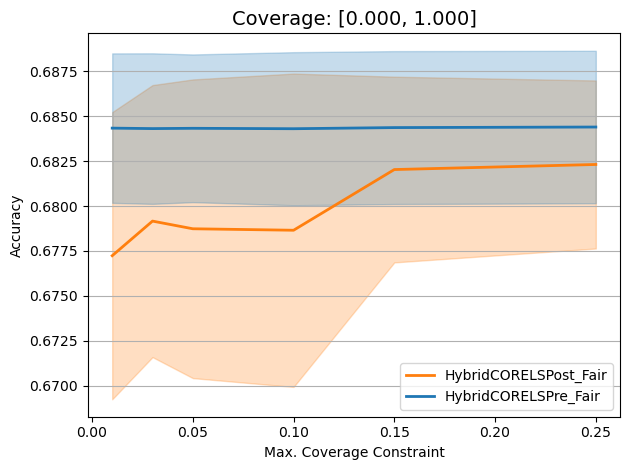

In [ ]:
all_max_cov = [0.01, 0.03, 0.05, 0.10, 0.15, 0.25]
Acc_Max_Coverage_one_quantile (Dataset_name, epsilon=0.05,split='train',seed=0, demographic_group='Gender', n_quantiles=1,all_max_cov= all_max_cov, quantile='q1' ,bins=None)

In [ ]:
def Sparsity_Max_Coverage_one_quantile (Dataset_name, epsilon,seed, demographic_group, n_quantiles,all_max_cov, quantile ,bins=None):

    mean = []
    std = []
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange'}
    label_fair = {'HybridCORELSPostClassifier': 'HybridCORELSPost_Fair', 
                'HybridCORELSPreClassifier' : 'HybridCORELSPre_Fair'}

    plt.figure(figsize=(7, 4))
    for method in ['HybridCORELSPostClassifier', 'HybridCORELSPreClassifier']:
        mean = []
        std = []
        for max_cov in [0.01, 0.03, 0.05, 0.10, 0.15, 0.25]:
            if max_cov == 0.05:
                result_dir = Path.cwd()/'Mitigation_results'/'Gender'
            else: 
                result_dir = Path.cwd()/'Mitigation_results'/'MGender'
            
            epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon, max_cov=max_cov if max_cov!=0.05 else None)
            mean.append (np.mean([len(model['rules']) for model in epsilon_rashomon_per_quantile[quantile]]))
            std.append( np.std([len(model['rules']) for model in epsilon_rashomon_per_quantile[quantile]]))
  

        plt.plot(
            all_max_cov,
            mean,
            label = label_fair[method],
            linewidth=2, color = color_map[method]
        )

        plt.fill_between(
            all_max_cov,
            np.array(mean) - np.array(std),
            np.array(mean) + np.array(std),
            color= color_map[method],
            alpha=0.25
        )
    n_q = n_quantiles
    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)


    plt.legend()
    plt.xlabel(f'Max. Coverage Constraint')
    plt.ylabel('Number of Rules')
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Fair'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Sparsity_maxcoverage_{Dataset_name}_{demographic_group}_{quantile}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()


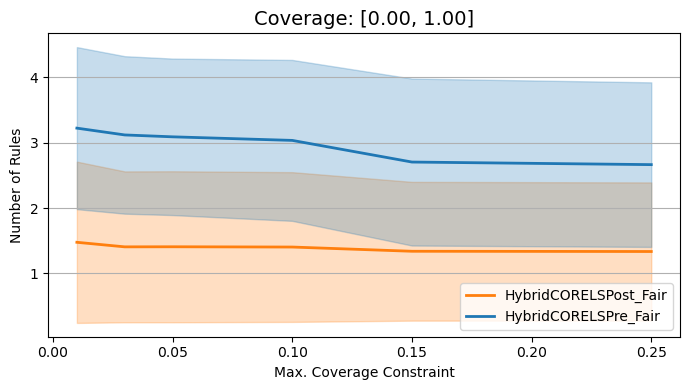

In [ ]:
Sparsity_Max_Coverage_one_quantile (Dataset_name, epsilon,seed, demographic_group, n_quantiles=1,all_max_cov= all_max_cov, quantile='q1' ,bins=None)


In [ ]:
def Max_DeltaICF_Max_Coverage_one_quantile(Dataset_name,seed, epsilon, split, demographic_group, n_quantiles,all_max_cov, quantile ,bins=None):
  
    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)


    mean = []
    std = []
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange'}
    label_fair = {'HybridCORELSPostClassifier': 'HybridCORELSPost_Fair', 
                'HybridCORELSPreClassifier' : 'HybridCORELSPre_Fair'}

    plt.figure(figsize=(7, 4))
    for method in ['HybridCORELSPostClassifier', 'HybridCORELSPreClassifier']:
        mean = []
        std = []
        for max_cov in all_max_cov:
            if max_cov == 0.05:
                result_dir = Path.cwd()/'Mitigation_results'/'Gender'
            else: 
                result_dir = Path.cwd()/'Mitigation_results'/'MGender'
            
            epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon, max_cov=max_cov if max_cov!=0.05 else None)
           
            n_q = len(epsilon_rashomon_per_quantile)
            q = quantile 

            conditions = my_data.demographicGroup(summarized=True)[demographic_group]

            eval = Evaluation(X[split], features, conditions)

            all_icf_disparity = []

            for model in epsilon_rashomon_per_quantile[q]:
                ICF = eval.compute_fairness(model[f'preds_types_{split}'])
                ICF_disparity = eval.compute_ICF_disparity(ICF)

                all_icf_disparity.append(ICF_disparity['over_all_groups'])


            mean.append(np.mean(all_icf_disparity))
            std.append(np.std(all_icf_disparity))



        plt.plot(
            all_max_cov,
            mean,
            label = label_fair[method],
            linewidth=2, color = color_map[method]
        )

        plt.fill_between(
            all_max_cov,
            np.array(mean) - np.array(std),
            np.array(mean) + np.array(std),
            color= color_map[method],
            alpha=0.25)
        
    n_q = n_quantiles
    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)


    plt.legend()
    plt.xlabel(f'Max. Coverage Constraint')
    plt.ylabel('Max. Interpretability Coverage Disparity')
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Fair'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Max_Delta_ICF_MaxCoevrage_{Dataset_name}_{demographic_group}_{quantile}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()

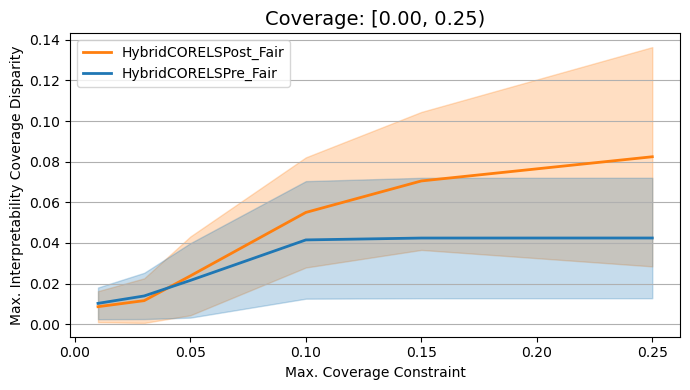

In [ ]:
all_max_cov = [0.01, 0.03, 0.05, 0.10, 0.15, 0.25]
Max_DeltaICF_Max_Coverage_one_quantile(Dataset_name=Dataset_name,seed=seed, epsilon=epsilon,split = split,\
                                demographic_group=demographic_group, n_quantiles=4,all_max_cov=all_max_cov, quantile='q1' ,bins=None)
    

In [ ]:
            all_EO = []

            for model in epsilon_rashomon_per_quantile[q]:
                CM = eval.confusion_matrix(model[f'preds_{split}'],y[split],model[f'preds_types_{split}'])
                TPR = eval.compute_true_pos_ratio(CM)
                EO = eval.compute_Equal_Opportunity(TPR, model_part='TPR_overal')
                all_EO.append(EO['over_all_groups'])

            mean_EO.append(np.mean(all_EO))
            std_EO.append(np.std(all_EO))

In [ ]:
def Max_EO_Max_Coverage_one_quantile(Dataset_name,seed, epsilon, split, demographic_group, n_quantiles,all_max_cov, quantile ,bins=None):
  
    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)


    mean = []
    std = []
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange'}
    label_fair = {'HybridCORELSPostClassifier': 'HybridCORELSPost_Fair', 
                'HybridCORELSPreClassifier' : 'HybridCORELSPre_Fair'}

    plt.figure(figsize=(7, 4))
    for method in ['HybridCORELSPostClassifier', 'HybridCORELSPreClassifier']:
        mean = []
        std = []
        for max_cov in all_max_cov:
            if max_cov == 0.05:
                result_dir = Path.cwd()/'Mitigation_results'/'Gender'
            else: 
                result_dir = Path.cwd()/'Mitigation_results'/'MGender'
            
            epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon, max_cov=max_cov if max_cov!=0.05 else None)
           
            n_q = len(epsilon_rashomon_per_quantile)
            q = quantile 

            conditions = my_data.demographicGroup(summarized=True)[demographic_group]

            eval = Evaluation(X[split], features, conditions)

            all_EO = []

            for model in epsilon_rashomon_per_quantile[q]:
                CM = eval.confusion_matrix(model[f'preds_{split}'],y[split],model[f'preds_types_{split}'])
                TPR = eval.compute_true_pos_ratio(CM)
                EO = eval.compute_Equal_Opportunity(TPR, model_part='TPR_overal')
                all_EO.append(EO['over_all_groups'])

            mean.append(np.mean(all_EO))
            std.append(np.std(all_EO))

        plt.plot(
            all_max_cov,
            mean,
            label = label_fair[method],
            linewidth=2, color = color_map[method]
        )

        plt.fill_between(
            all_max_cov,
            np.array(mean) - np.array(std),
            np.array(mean) + np.array(std),
            color= color_map[method],
            alpha=0.25)
        
    n_q = n_quantiles
    i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
    label = (
            f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})"
            if i < n_q - 1
            else f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
    # Global title
    plt.title(f"Coverage: {label}", fontsize=14)


    plt.legend()
    plt.xlabel(f'Max. Coverage Constraint')
    plt.ylabel('Max. Equal Opportunity')
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Fair'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Max_EO_MaxCoverage_{Dataset_name}_{demographic_group}_{quantile}.png"
    #plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()

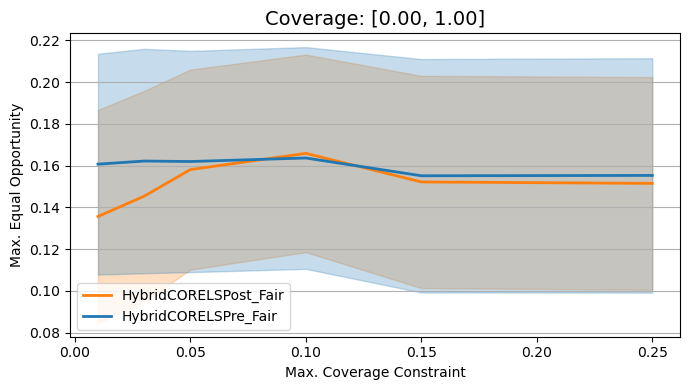

In [ ]:
Max_EO_Max_Coverage_one_quantile(Dataset_name=Dataset_name,seed=seed, epsilon=epsilon,split = split,\
                                  demographic_group=demographic_group, n_quantiles=1,all_max_cov=all_max_cov, quantile='q1' ,bins=None)

In [ ]:
all_max_cov

[0.01, 0.03, 0.05, 0.1, 0.15, 0.25]

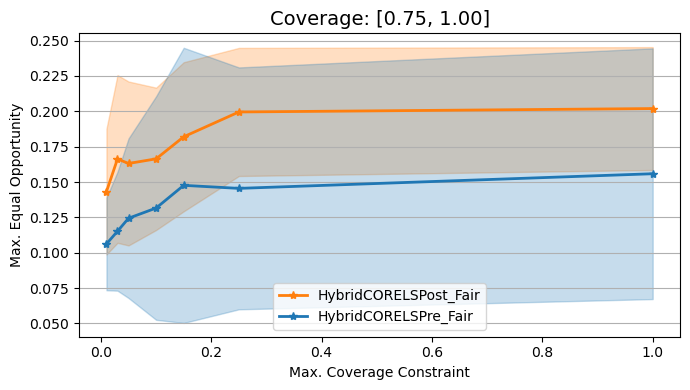

In [ ]:
all_max_cov = [0.01, 0.03, 0.05, 0.1, 0.15, 0.25, 1]
bins = None
n_quantiles = 4
epsilon =0.01
seed = 0 
quantile = 'q4'
np.random.seed(seed)

train_proportion = 0.8

my_data = Dataset.from_csv(
    Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
    Dataset_name
)
my_data.pre_process()

X, y, features, prediction = my_data.get_data_norulemining(
    {"train": train_proportion, "test": 1-train_proportion},
    random_state_param=seed)


mean = []
std = []
color_map = {
'HybridCORELSPreClassifier': 'tab:blue',
'HybridCORELSPostClassifier': 'tab:orange'}
label_fair = {'HybridCORELSPostClassifier': 'HybridCORELSPost_Fair', 
            'HybridCORELSPreClassifier' : 'HybridCORELSPre_Fair'}

plt.figure(figsize=(7, 4))
for method in ['HybridCORELSPostClassifier', 'HybridCORELSPreClassifier']:
    mean = []
    std = []
    for max_cov in all_max_cov:
        if max_cov == 0.05:
            result_dir = Path.cwd()/'Mitigation_results'/'Gender'
        elif max_cov == 1:
            result_dir = Path.cwd()/'bootstrap_results'
        else: 
            result_dir = Path.cwd()/'Mitigation_results'/'MGender'
        
        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon (Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon, max_cov= None if max_cov in [0.05, 1] else max_cov)
        
        n_q = len(epsilon_rashomon_per_quantile)
        q = quantile 

        conditions = my_data.demographicGroup(summarized=True)[demographic_group]

        eval = Evaluation(X[split], features, conditions)

        all_EO = []

        for model in epsilon_rashomon_per_quantile[q]:
            CM = eval.confusion_matrix(model[f'preds_{split}'],y[split],model[f'preds_types_{split}'])
            TPR = eval.compute_true_pos_ratio(CM)
            EO = eval.compute_Equal_Opportunity(TPR, model_part='TPR_overal')
            all_EO.append(EO['over_all_groups'])

        mean.append(np.mean(all_EO))
        std.append(np.std(all_EO))

    plt.plot(
        all_max_cov,
        mean,
        label = label_fair[method],
        linewidth=2, color = color_map[method],
        marker='*',  
    )

    plt.fill_between(
        all_max_cov,
        np.array(mean) - np.array(std),
        np.array(mean) + np.array(std),
        color= color_map[method],
        alpha=0.25)
    
n_q = n_quantiles
i = list(epsilon_rashomon_per_quantile.keys()).index(quantile)
label = (
        f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})"
        if i < n_q - 1
        else f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
# Global title
plt.title(f"Coverage: {label}", fontsize=14)


plt.legend()
plt.xlabel(f'Max. Coverage Constraint')
plt.ylabel('Max. Equal Opportunity')
#plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

plt.grid(axis='y')
plt.tight_layout()
# --- save ---
output_dir = Path.cwd()/'plots'/'Fair'
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"Max_EO_MaxCoverage_{Dataset_name}_{demographic_group}_oneq.png"
#plt.savefig(output_file, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:

def CDF_individual_arbitrariness_all_methods(Dataset_name,seed, result_dir,epsilon,split,n_quantiles, bins):
    """This function generates a plot comparing the average individual arbitrariness 
    across different methods for a given dataset. 
    It computes the Rashomon sets for each method, 
    calculates the average individual arbitrariness for models in each quantile of coverage rate, and plot it via a CDF
    .

    """

    methods = [
        'HybridCORELSPreClassifier',
        'HybridCORELSPostClassifier',
        'HyRS',
        'CRL'
    ]


    plt.figure(figsize=(7, 4))

    color_map = {
        'HybridCORELSPreClassifier': 'tab:blue',
        'HybridCORELSPostClassifier': 'tab:orange',
        'HyRS': 'tab:green',
        'CRL': 'tab:red'
    }

    for m_idx, method in enumerate(methods):

        # --- compute Rashomon sets ---

        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
        Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
        )
        # --- compute arbitrariness ---
        for i, q in enumerate(epsilon_rashomon_per_quantile.keys()):
            ax = axes[i]

            pred_types_list = []
            for model in epsilon_rashomon_per_quantile[q]:
                pred_types_list.append(model[f'preds_types_{split}'])

            if len(pred_types_list) == 0:
                continue

            all_models_pred_type = np.column_stack(pred_types_list)
            arbitrariness = np.mean(all_models_pred_type, axis=1) #average of predcition type across Rashomon set
            # Sort values for empirical CDF
            x = np.sort(arbitrariness)
            y = np.arange(1, len(x) + 1) / len(x)

            plt.step(
                x,
                y,
                where='post',
                linewidth=2,
                color=color_map[method],
                label=method
            )
                
        

    # -------------------------------
    # Formatting per subplot
    # -------------------------------
    for i, ax in enumerate(axes):
        lower = quantiles[i]
        upper = quantiles[i+1]

        label = f"[{lower:.2f}, {upper:.2f})" if i < 3 else f"[{lower:.2f}, {upper:.2f}]"
        ax.set_xlabel("Individual Arbitrariness")
        ax.set_ylabel("Proportion of Data Points")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(f"Coverage: {label}", fontsize=10)
        ax.grid(True)
        # ax.text(
        # 0.07, 0.95,                      # position (relative to axes)
        # f"Coverage: {label}",
        # transform=ax.transAxes,
        # fontsize=10,
        # verticalalignment='top'
        # )

    # Shared legend
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='lower center', ncol=4)

    #fig.suptitle(f"{dataset_name.capitalize()} | Individual Arbitrariness", fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    output_dir = Path.cwd()/'plots'/'Arbit'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"CDF_Individual_arbitrariness_{Dataset_name}.png"
    #plt.savefig(output_file, bbox_inches="tight")

    plt.show()
    plt.close()

In [ ]:
def CDF_individual_arbitrariness_all_methods(
    Dataset_name, seed, result_dir, epsilon, split, n_quantiles, bins):
    """Generate one CDF plot per coverage quantile for individual arbitrariness."""

    methods = [
        'HybridCORELSPreClassifier',
        'HybridCORELSPostClassifier',
        'HyRS',
        'CRL'
    ]

    color_map = {
        'HybridCORELSPreClassifier': 'tab:blue',
        'HybridCORELSPostClassifier': 'tab:orange',
        'HyRS': 'tab:green',
        'CRL': 'tab:red'
    }

    output_dir = Path.cwd() / 'plots' / 'Arbit'
    output_dir.mkdir(exist_ok=True)

    # Store CDF data for each quantile and method
    cdf_data = {q_idx: {} for q_idx in range(n_quantiles)}
    quantiles = None
    mean_ICA = {method:[] for method in methods}
    std_ICA = {method:[] for method in methods}
    median_ICA = {method:[] for method in methods}
    for method in methods:

        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
            Dataset_name,
            method,
            result_dir,
            seed=seed,
            n_quantiles=n_quantiles,
            bins=bins,
            epsilon=epsilon
        )

        for q_idx, q in enumerate(epsilon_rashomon_per_quantile.keys()):

            pred_types_list = []

            for model in epsilon_rashomon_per_quantile[q]:
                pred_types_list.append(model[f'preds_types_{split}'])

            if len(pred_types_list) == 0:
                continue

            all_models_pred_type = np.column_stack(pred_types_list)
            arbitrariness = np.mean(all_models_pred_type, axis=1)
            ICA = 1 - 2*np.abs((arbitrariness-0.5))
            mean_ICA[method].append(np.mean(ICA))
            median_ICA[method].append(np.median(ICA))
            std_ICA[method].append(np.std(ICA))
            x = np.sort(ICA)
            y = np.arange(1, len(x) + 1) / len(x)

            cdf_data[q_idx][method] = (x, y)

    # Create and save one plot per quantile
    for q_idx in range(n_quantiles):

        fig, ax = plt.subplots(figsize=(6, 4))

        for method in methods:
            if method not in cdf_data[q_idx]:
                continue

            x, y = cdf_data[q_idx][method]

            ax.step(
                x,
                y,
                where='post',
                linewidth=2,
                color=color_map[method],
                label=method
            )

        lower = quantiles[q_idx]
        upper = quantiles[q_idx + 1]

        coverage_label = (
            f"[{lower:.2f}, {upper:.2f})"
            if q_idx < n_quantiles - 1
            else f"[{lower:.2f}, {upper:.2f}]"
        )

        ax.set_title(f"Coverage: {coverage_label}", fontsize=12)
        ax.set_xlabel("Individual Arbitrariness", fontsize = 14)
        ax.set_ylabel("Proportion of Data Points",fontsize = 14)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)
        #ax.legend(loc="best", fontsize=9)

        plt.tight_layout()

        output_file = (
            output_dir
            / f"CDF_Individual_arbitrariness_{Dataset_name}_q{q_idx + 1}.png"
        )

        plt.show()
        #plt.savefig(output_file, bbox_inches="tight")
        plt.close()
    return mean_ICA,median_ICA, std_ICA

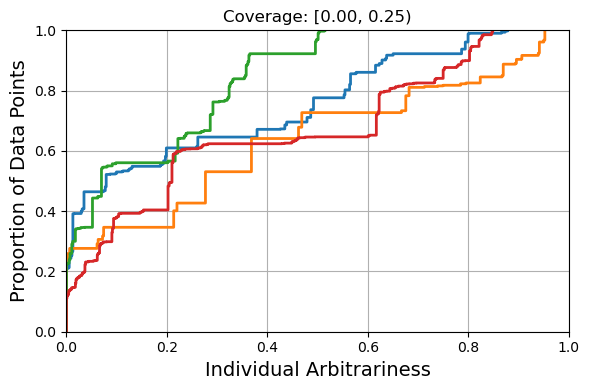

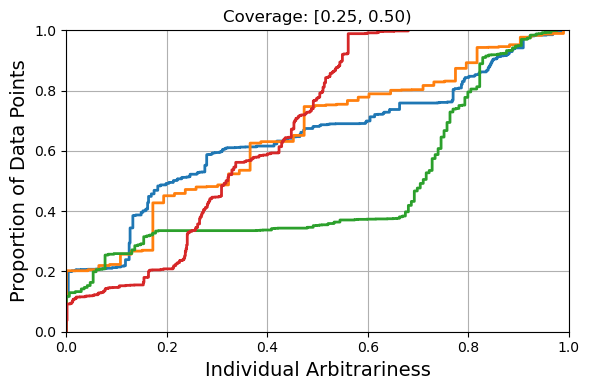

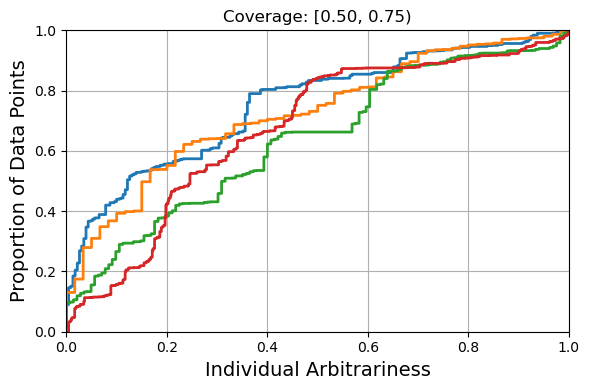

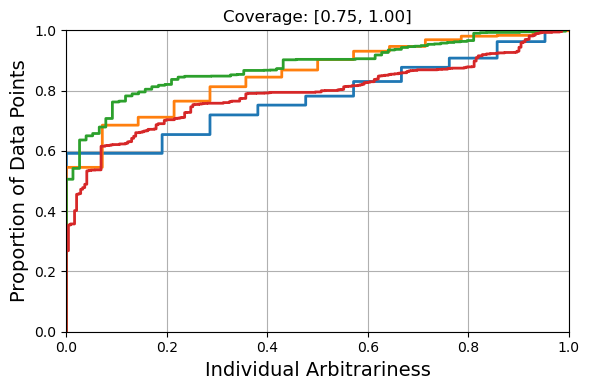

In [ ]:
mean_ICA,median_ICA, std_ICA = CDF_individual_arbitrariness_all_methods(
    Dataset_name='compas', seed=0, result_dir=result_dir, epsilon=0.01, split='test', n_quantiles=4, bins=None
)

In [ ]:
mean_ICA

{'HybridCORELSPreClassifier': [np.float64(0.24156370565210344),
  np.float64(0.3549550822278094),
  np.float64(0.2458934823359986),
  np.float64(0.22202422202422203)],
 'HybridCORELSPostClassifier': [np.float64(0.3575989262263771),
  np.float64(0.34755847659073463),
  np.float64(0.27417417417417417),
  np.float64(0.14676764676764675)],
 'HyRS': [np.float64(0.16000133889221546),
  np.float64(0.5226291380137533),
  np.float64(0.36276276276276276),
  np.float64(0.11953129600188422)],
 'CRL': [np.float64(0.3247563850915806),
  np.float64(0.32562208510761564),
  np.float64(0.3277768600107431),
  np.float64(0.2091147162141077)]}

In [ ]:
mean_ICA = pd.DataFrame(mean_ICA).transpose()
    



In [ ]:
median_ICA = pd.DataFrame(median_ICA).transpose()
median_ICA.columns = ['q1', 'q2', 'q3', 'q4']

In [ ]:
mean_ICA.columns = ['q1', 'q2', 'q3', 'q4']
std_ICA = pd.DataFrame(std_ICA).transpose()


In [ ]:
median_ICA

,q1,q2,q3,q4
HybridCORELSPreClassifier,0.079190,0.213039,0.121475,0.000000
HybridCORELSPostClassifier,0.276688,0.322581,0.166667,0.000000
HyRS,0.069767,0.710059,0.315789,0.000000
CRL,0.210056,0.317685,0.245877,0.040568


In [ ]:
std_ICA


,q1,q2,q3,q4
HybridCORELSPreClassifier,0.275401,0.323523,0.265512,0.313719
HybridCORELSPostClassifier,0.328826,0.291657,0.275913,0.232196
HyRS,0.163629,0.341107,0.287334,0.224721
CRL,0.300740,0.177054,0.257055,0.306599


In [ ]:

ESTIMATORS = {

    "HybridCORELSPreClassifier": {
        "build": lambda bbox, h: HybridCORELSPreClassifier(
            black_box_classifier=bbox,
            beta=h["beta"],
            c = h["lambdaValue"],
            alpha=h["alpha"],
            min_coverage=h["min_coverage"],
            obj_mode='collab',
            **h["corels_params"]
        ),
        "fit": lambda model, X, y, h: model.fit(X, y, features=h["features"],
                                                                prediction_name=h['prediction_name'], time_limit=h["time_limit"],
                                                                memory_limit=h["memory_limit"]),
        "hparams": {
            "alpha": 2,
            "lambdaValue" : 0.001,
            "beta": lambda X,lambdaValue : min([ (1 / X.shape[0]) / 2, lambdaValue / 2]),
            "memory_limit": 8000,
            "min_coverage": [0.1,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95]
        },
    },

    "HybridCORELSPostClassifier": {
        "build": lambda bbox, h: HybridCORELSPostClassifier(
            black_box_classifier=bbox,
            beta=h["beta"],
            c = h["lambdaValue"],
            min_coverage=h["min_coverage"],
            bb_pretrained=False,
            **h["corels_params"]
        ),
        "fit": lambda model, X, y, h: model.fit(X, y, features=h["features"],
                                                                prediction_name=h['prediction_name'], time_limit=h["time_limit"],
                                                                memory_limit=h["memory_limit"]),
        "hparams": {
            "beta": lambda X,lambdaValue : min([ (1 / X.shape[0]) / 2, lambdaValue / 2]),
            "lambdaValue" : 0.001,
            "memory_limit": 8000,
            "min_coverage": [0.1,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95]
        },
    },

    "HyRS": {
        "build": lambda bbox, h: HybridRuleSetClassifier(
            bbox,
            alpha=h["alpha"],
            beta=h["beta"]
        ),
        "fit": lambda model, X, y, h: model.fit(
            X, y,
            h["n_iteration"],
            T0=h["T0"],
            premined_rules=True,
            random_state=h["seed"],
            time_limit=h["time_limit"]
        ),
        "hparams": {
            "alpha": 0.001,
            "beta": [0.001, 0.00215443, 0.00464159, 0.01, 0.02154435,
                        0.04641589, 0.1, 0.21544347, 0.46415888, 1.0], #changed from 0.02 to 0.1 
            "n_iteration": 10**7, 
            "T0": 0.01,
        },
    },

    "CRL": {
        "build": lambda bbox, h: CRL(
            bbox,
            max_card=h["max_card"],
            alpha=h["alpha"]
        ),
        "fit": lambda model, X, y, h: model.fit(
            X, y,
            n_iteration=h["n_iteration"],
            random_state=h["seed"],
            premined_rules=True,
            time_limit=h["time_limit"]
        ),
        "hparams": {
            "max_card": 2,
            "alpha": [0.001, 0.0016681, 0.00278256, 0.00464159, 0.00774264,
                        0.0129155,0.02154435, 0.03593814, 0.05994843, 0.1], ##I think 0.01 is better 
            "n_iteration": 10**7,#50000
        },
    },
}

#Shared CORELS parameters
CORELS_PARAMS = {
    "policy": "objective",
    "max_card": 1,
    "n_iter": 10**9,
    'min_support':0.05,
    "verbosity": ["hybrid"],
}

# Trade-off parameter name for each model
TRADEOFF_PARAM = {
    "HybridCORELSPreClassifier": "min_coverage",
    "HybridCORELSPostClassifier": "min_coverage",
    "CRL": "alpha",
    "HyRS": "beta",
}

TRADEOFF_VALUES = {"HybridCORELSPreClassifier": ESTIMATORS["HybridCORELSPreClassifier"]["hparams"]["min_coverage"],
                   "HybridCORELSPostClassifier": ESTIMATORS["HybridCORELSPostClassifier"]["hparams"]["min_coverage"],
                   "CRL": ESTIMATORS["CRL"]["hparams"]["alpha"],
                   "HyRS": ESTIMATORS["HyRS"]["hparams"]["beta"]}


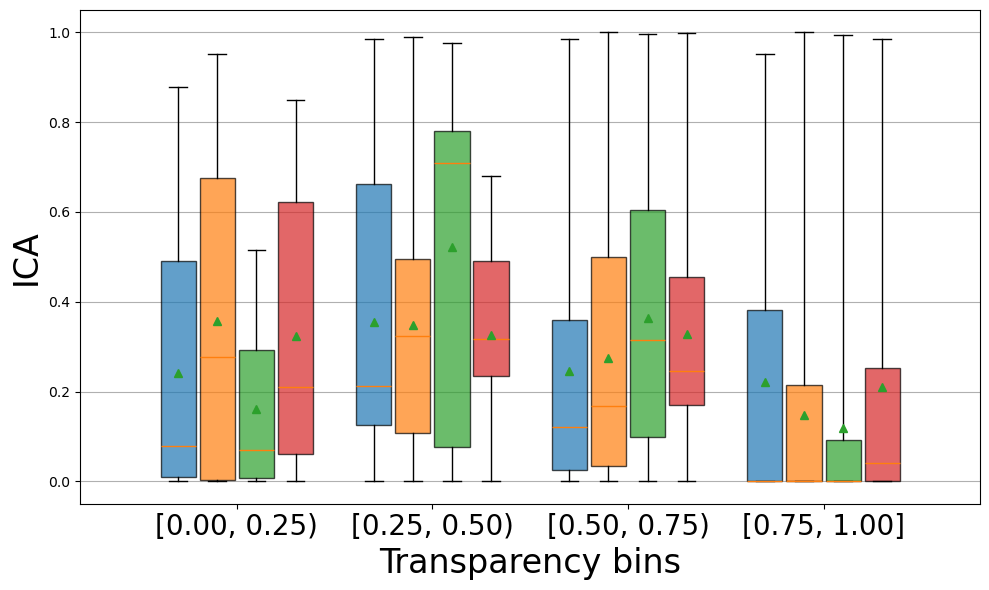

In [ ]:

result_dir = Path.cwd()/"bootstrap_results"
bins = None
Dataset_name = 'compas'
epsilon = 0.01
split = 'test'
n_quantiles = 4
seed = 0 


def ICA_box_all_methods (Dataset_name, seed,split, result_dir, epsilon, n_quantiles, bins):
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)
    color_map = {
    'HybridCORELSPreClassifier': 'tab:blue',
    'HybridCORELSPostClassifier': 'tab:orange',
    'HyRS': 'tab:green',
    'CRL': 'tab:red'
    }

    plt.figure(figsize=(10, 6))
    LABEL_SIZE = 24
    TICK_SIZE = 20
    LEGEND_SIZE = 18
    TITLE_SIZE = 24
    for i,method in enumerate(ESTIMATORS):
        # -------------------------------
        # Collect Rashomon models
        # -------------------------------

        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
        Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
        )
            # -------------------------------
        # Compute statistics
        # -------------------------------
        

        all_ICA = []

        for q in epsilon_rashomon_per_quantile.keys():

            pred_types_list = []

            for model in epsilon_rashomon_per_quantile[q]:
                pred_types_list.append(model[f'preds_types_{split}'])

            if len(pred_types_list) == 0:
                continue

            all_models_pred_type = np.column_stack(pred_types_list)
            arbitrariness = np.mean(all_models_pred_type, axis=1)
            ICA = 1 - 2*np.abs((arbitrariness-0.5))
            all_ICA.append(ICA)


        num_methods = len(ESTIMATORS)
        num_quantiles = len(epsilon_rashomon_per_quantile.keys())

        base_positions = np.arange(1, num_quantiles + 1)

        # dynamic spacing
        total_width = 0.8
        width = total_width / num_methods


        # --- BOX PLOTS ---
        # center all groups
        positions = base_positions + (i - (num_methods - 1)/2) * width

        box = plt.boxplot(
            all_ICA,
            positions=positions,
            widths=width * 0.9,
            showmeans=True,
            whis=[0, 100],
            patch_artist=True
        )

        for patch in box['boxes']:
            patch.set_facecolor(color_map[method])
            patch.set_alpha(0.7)



    #plt.legend()

    plt.xlabel(f'Transparency bins', fontsize= LABEL_SIZE)
    plt.ylabel('ICA', fontsize= LABEL_SIZE)
    #plt.title(f'{Dataset_name.capitalize()}')

    labels = []
    for i in range(len(quantiles) - 1):
        if i < len(quantiles) - 2:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
        else:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")
        # --- LEGENDS ---
    # boxplot legend (groups)
    # legend_elements = [
    #     Patch(facecolor=color_map[method], label=method)
    #     for i, method in enumerate(ESTIMATORS)
    # ]

    #plt.legend(handles=legend_elements, loc='upper left')
    plt.xticks(base_positions, labels, fontsize=TICK_SIZE)
    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Arbit'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"ICA_Box_{Dataset_name}_{split}_{epsilon}.png"
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()  

In [60]:
def Fair_ICA_all_methods (Dataset_name,seed, epsilon,split, n_quantiles, bins=None):
    result_dir ={'HybridCORELSPre_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
                'HybridCORELSPost_Fair': Path.cwd()/"Mitigation_results"/demographic_group,
                'HybridCORELSPre': Path.cwd()/"bootstrap_results",
                'HybridCORELSPost': Path.cwd()/"bootstrap_results"}
    method_match = {'HybridCORELSPre_Fair':'HybridCORELSPreClassifier',
                    'HybridCORELSPre':'HybridCORELSPreClassifier',
                    'HybridCORELSPost_Fair':'HybridCORELSPostClassifier',
                    'HybridCORELSPost':'HybridCORELSPostClassifier'}
    seed = 0 
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed)
    color_map = {
        'HybridCORELSPre_Fair': '#1f77b4',   # strong blue
        'HybridCORELSPost_Fair': '#ff7f0e',  # strong orange
        'HybridCORELSPre': '#aec7e8',             # light blue
        'HybridCORELSPost': '#ffbb78'             # light orange
    }
    plt.figure(figsize=(10, 6))
    LABEL_SIZE = 24
    TICK_SIZE = 20
    LEGEND_SIZE = 18
    TITLE_SIZE = 24
  
 

    for i,j in enumerate(method_match.keys()):
        # -------------------------------
        # Collect Rashomon models
        # -------------------------------
    
        epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
        Dataset_name, method_match[j], result_dir[j], seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
        )
            # -------------------------------
        # Compute statistics
        # -------------------------------
        

        all_ICA = []

        for q in epsilon_rashomon_per_quantile.keys():

            pred_types_list = []

            for model in epsilon_rashomon_per_quantile[q]:
                pred_types_list.append(model[f'preds_types_{split}'])

            if len(pred_types_list) == 0:
                continue

            all_models_pred_type = np.column_stack(pred_types_list)
            arbitrariness = np.mean(all_models_pred_type, axis=1)
            ICA = 1 - 2*np.abs((arbitrariness-0.5))
            all_ICA.append(ICA)

        num_methods = len(method_match)
        num_quantiles = len(epsilon_rashomon_per_quantile.keys())

        base_positions = np.arange(1, num_quantiles + 1)

        # dynamic spacing
        total_width = 0.8
        width = total_width / num_methods


        # --- BOX PLOTS ---
        # center all groups
        positions = base_positions + (i - (num_methods - 1)/2) * width

        box = plt.boxplot(
            all_ICA,
            positions=positions,
            widths=width * 0.9,
            showmeans=True,
            whis=[0, 100],
            patch_artist=True
        )

        for patch in box['boxes']:
            patch.set_facecolor(color_map[j])


    #fontsize=LABEL_SIZE
    plt.xlabel(f'Quantiles of Coverage Rate', fontsize=LABEL_SIZE)
    plt.ylabel('ICD', fontsize=LABEL_SIZE)
    #plt.title(f'{Dataset_name.capitalize()} | {demographic_group}')

    labels = []
    for i in range(len(quantiles) - 1):
        if i < len(quantiles) - 2:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
        else:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")


    # --- LEGENDS ---
    # boxplot legend (groups)
    # legend_elements = [
    #     Patch(facecolor=color_map[method], label=method)
    #     for i, method in enumerate(method_match)
    # ]

    # plt.legend(handles=legend_elements, loc='upper left')
    plt.xticks(base_positions, labels, fontsize=TICK_SIZE) #, fontsize=TICK_SIZE
    plt.yticks(fontsize=TICK_SIZE)
    plt.grid(axis='y')
    plt.tight_layout()
    # --- save ---
    output_dir = Path.cwd()/'plots'/'Arbit'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Fair_ICA{Dataset_name}.png"
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()
    plt.close()


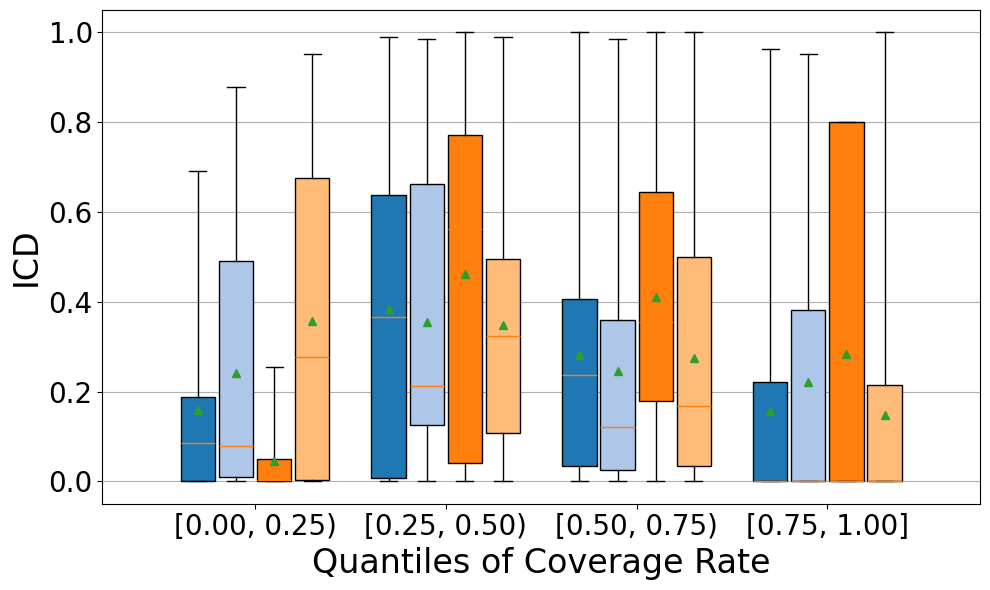

In [61]:
Fair_ICA_all_methods(Dataset_name = 'compas',seed = 0, epsilon = 0.01,split = 'test', n_quantiles=4, bins=None)

In [79]:
def comprehensive_ICF_plot_2_axis_quantiles(Dataset_name,method,seed, result_dir, n_quantiles ,epsilon,bins,split, demographic_group):
    np.random.seed(seed)

    train_proportion = 0.8

    my_data = Dataset.from_csv(
        Path.cwd().parent / f'examples/data/{Dataset_name}_mined.csv',
        Dataset_name
    )
    my_data.pre_process()

    X, y, features, prediction = my_data.get_data_norulemining(
        {"train": train_proportion, "test": 1-train_proportion},
        random_state_param=seed
    )


    conditions = my_data.demographicGroup(summarized=True)[demographic_group]
    eval = Evaluation(X[split], features, conditions)



    # --- compute Rashomon Set ---
    epsilon_rashomon_per_quantile, _, quantiles = generate_quantiles_Rashomon(
    Dataset_name, method, result_dir, seed=seed, n_quantiles=n_quantiles, bins=bins, epsilon=epsilon
    )

    # -------------------------------
    # Compute statistics
    # -------------------------------
    All_all = {cond: [] for cond in conditions}
    mean_icf_disparity = []
    std_icf_disparity = []
    for q in epsilon_rashomon_per_quantile.keys():

        all_icf = {cond: [] for cond in conditions}
        all_icf_disparity = []

        for model in epsilon_rashomon_per_quantile[q]:
            ICF = eval.compute_fairness(model[f'preds_types_{split}'])
            ICF_disparity = eval.compute_ICF_disparity(ICF)

            all_icf_disparity.append(ICF_disparity['over_all_groups'])

            for cond in conditions:
                all_icf[cond].append(ICF[cond])

        mean_icf_disparity.append(np.mean(all_icf_disparity))
        std_icf_disparity.append(np.std(all_icf_disparity))

        for cond in conditions:
            All_all[cond].append(all_icf[cond])

    # -------------------------------
    # PLOTTING (UPDATED FOR ANY #GROUPS)
    # -------------------------------
        
    # Using two y axes due to scale difference
    fig, ax1 = plt.subplots(figsize=(10, 6))

    LABEL_SIZE = 20
    TICK_SIZE = 17
    LEGEND_SIZE = 14
    TITLE_SIZE = 18
    
    num_groups = len(conditions)
    num_quantiles = len(epsilon_rashomon_per_quantile.keys())

    base_positions = np.arange(1, num_quantiles + 1)

    # dynamic spacing
    total_width = 0.8
    width = total_width / num_groups

    # dynamic colors
    colors = plt.cm.tab10(np.linspace(0, 1, num_groups))

    # --- BOX PLOTS (left axis) ---
    for i, cond in enumerate(conditions):

        # center all groups
        positions = base_positions + (i - (num_groups - 1)/2) * width

        box = ax1.boxplot(
            All_all[cond],
            positions=positions,
            widths=width * 0.9,
            showmeans=True,
            whis=[0, 100],
            patch_artist=True
        )

        for patch in box['boxes']:
            patch.set_facecolor(colors[i])

   
    ax1.set_ylabel(
        'Interpretability Coverage',
        fontsize=LABEL_SIZE)

    ax1.set_xlabel(
        'Transparency bins',
        fontsize=LABEL_SIZE)
    # --- SECOND AXIS (right) ---

    ax2 = ax1.twinx()

    line_color = "red"
    shade_color = "lightcoral"

    ax2.plot(
        base_positions,
        mean_icf_disparity,
        color=line_color,
        marker='o',
        linewidth=2.5,
        label='ICD'
    )

    ax2.fill_between(
        base_positions,
        np.array(mean_icf_disparity) - np.array(std_icf_disparity),
        np.array(mean_icf_disparity) + np.array(std_icf_disparity),
        color=shade_color,
        alpha=0.25)

    
    ax2.set_ylabel(
    'ICD',
    color=line_color,
    fontsize=LABEL_SIZE)

    # make right axis red
    ax1.tick_params(axis='both', labelsize=TICK_SIZE)
    ax2.tick_params(axis='y', labelsize=TICK_SIZE, colors=line_color)

    ax2.spines['right'].set_color(line_color)
    ax2.yaxis.label.set_color(line_color)
    ax2.set_ylim(bottom=0)
    ax1.set_ylim(bottom=0)
    # disparity legend (line)
    ax2.legend(loc='upper right', fontsize = LEGEND_SIZE)

    
    if demographic_group == 'Gender':
        # boxplot legend (groups)
        legend_elements = [
            Patch(facecolor=colors[i], label='Male $\eta$' if cond in ['gender_Male','Gender=Male', 'neg_Female'] else 'Female')
            for i, cond in enumerate(conditions)
        ]
    else:
        # boxplot legend (groups)
        legend_elements = [
            Patch(facecolor=colors[i], label=cond.capitalize())
            for i, cond in enumerate(conditions)
        ]

    ax1.legend(handles=legend_elements, loc='upper left', fontsize = LEGEND_SIZE)


    # --- formatting ---
    #plt.title(f'{Dataset_name.capitalize()} | {method}')
    ax1.set_xticks(base_positions)

    #to generate quantiles range labels
    labels = []
    for i in range(len(quantiles) - 1):
        if i < len(quantiles) - 2:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f})")
        else:
            labels.append(f"[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")

 
    ax1.set_xticklabels(labels, fontsize=TICK_SIZE)
    ax1.grid(axis='y')
    plt.tight_layout()
    # # --- save ---
    output_dir = Path.cwd()/'plots'/'ICF'
    output_dir.mkdir(exist_ok=True)

    output_file = output_dir / f"Comp_ICF_2axis{Dataset_name}_{method}_{demographic_group}_{split}_{epsilon}.pdf"
    
    # plt.savefig(
    # output_file,
    # bbox_inches="tight",
    # dpi=300)
    plt.show()
    plt.close()

In [74]:
DATASETS

['compas', 'adult', 'acs_employ']

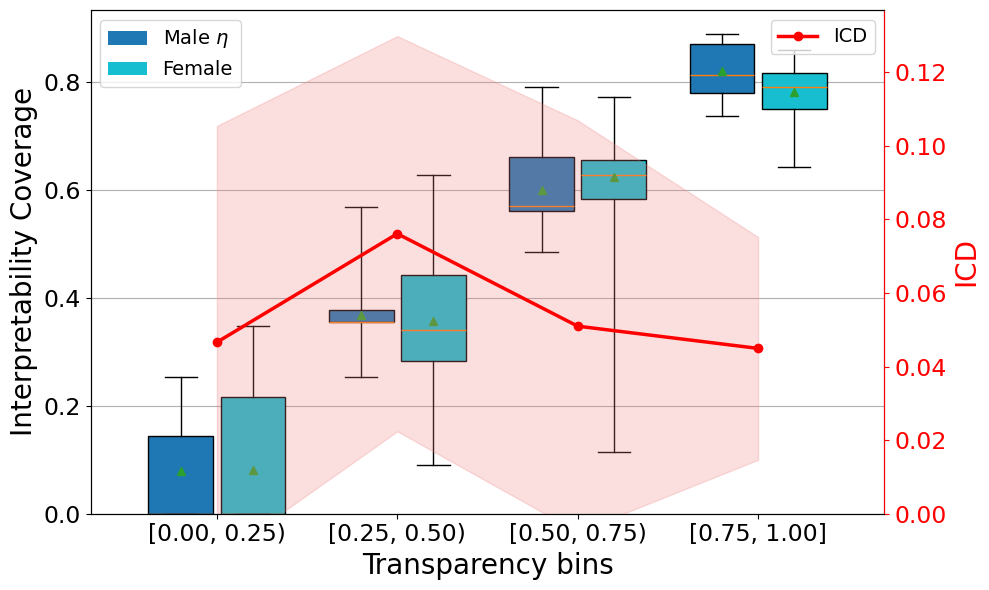

In [80]:

comprehensive_ICF_plot_2_axis_quantiles(Dataset_name='compas',method='HyRS',seed=0, result_dir=result_dir, n_quantiles=4 ,epsilon=0.01,bins=None,split='test', demographic_group='Gender')

In [15]:
# ===============================
# ESTIMATORS dictionary here:
# ===============================

ESTIMATORS = {

    "HybridCORELSPreClassifier": {
        "build": lambda bbox, h: HybridCORELSPreClassifier(
            black_box_classifier=bbox,
            beta=h["beta"],
            c = h["lambdaValue"],
            alpha=h["alpha"],
            min_coverage=h["min_coverage"],
            obj_mode='collab',
            **h["corels_params"]
        ),
        "fit": lambda model, X, y, h: model.fit(X, y, features=h["features"],
                                                                prediction_name=h['prediction_name'], time_limit=h["time_limit"],
                                                                memory_limit=h["memory_limit"]),
        "hparams": {
            "alpha": 2,
            "lambdaValue" : [10**-2, 10**-3, 10**-4],
            "beta": lambda X,lambdaValue : min([ (1 / X.shape[0]) / 2, lambdaValue / 2]),
            "memory_limit": 8000,
            "min_coverage": [0.1,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95],
            "max_lenght": [2**i for i in [1,2,3,4,5]]
        },
    },

    "HybridCORELSPostClassifier": {
        "build": lambda bbox, h: HybridCORELSPostClassifier(
            black_box_classifier=bbox,
            beta=h["beta"],
            c = h["lambdaValue"],
            min_coverage=h["min_coverage"],
            bb_pretrained=False,
            **h["corels_params"]
        ),
        "fit": lambda model, X, y, h: model.fit(X, y, features=h["features"],
                                                                prediction_name=h['prediction_name'], time_limit=h["time_limit"],
                                                                memory_limit=h["memory_limit"]),
        "hparams": {
            "beta": lambda X,lambdaValue : min([ (1 / X.shape[0]) / 2, lambdaValue / 2]),
            "lambdaValue" : [10**-2, 10**-3, 10**-4],
            "memory_limit": 8000,
            "min_coverage": [0.1,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95],
            "max_lenght": [2**i for i in [1,2,3,4,5]],
        },
    },
}

#Shared CORELS parameters
CORELS_PARAMS = {
    "policy": "objective",
    "max_card": 1,
    "n_iter": 10**9,
    'min_support':0.05,
    "verbosity": ["hybrid"],
}

# Trade-off parameter name for each model
TRADEOFF_PARAM = {
    "HybridCORELSPreClassifier": ["min_coverage", "lambdaValue", "max_lenght"],
    "HybridCORELSPostClassifier": ["min_coverage", "lambdaValue", "max_lenght"],
  
}

TRADEOFF_VALUES = {"HybridCORELSPreClassifier":
                   {k:ESTIMATORS["HybridCORELSPreClassifier"]["hparams"][k] for k in TRADEOFF_PARAM["HybridCORELSPreClassifier"] },
                   "HybridCORELSPostClassifier": {k:ESTIMATORS["HybridCORELSPostClassifier"]["hparams"][k] for k in TRADEOFF_PARAM["HybridCORELSPostClassifier"] }
}

# ===============================
# Experiment grid (FLATTENED)
# ===============================

n_seeds = 5
DATASETS = ["compas", "adult", "acs_employ"]
SEEDS = [1,2,3,4,5]


EXPERIMENTS = []

for dataset in DATASETS:
    for model in ['HybridCORELSPostClassifier']:
        for min_cov in TRADEOFF_VALUES['HybridCORELSPostClassifier']['min_coverage']:
            for depth in TRADEOFF_VALUES['HybridCORELSPostClassifier']['max_lenght']:
                for lambda_val in TRADEOFF_VALUES['HybridCORELSPostClassifier']['lambdaValue']:
                    for seed in SEEDS:

                        EXPERIMENTS.append({
                            "dataset": dataset,
                            "model": model,
                            "min_coverage": min_cov,
                            "max_lenght": depth,
                            "lambdaValue": lambda_val,
                            "seed": seed,
                        })

In [18]:
len(EXPERIMENTS)/3

750.0

In [20]:
from pathlib import Path

In [24]:
for i in (Path.cwd()/'models').iterdir():
    print(i)

/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/acs_employ_random_forest_4.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/compas_random_forest_5.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/adult_random_forest_2.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/compas_random_forest_1.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/acs_employ_random_forest_2.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/adult_random_forest_4.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/compas_random_forest_3.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/acs_employ_random_forest_5.pickle
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/paper/models/adu

In [26]:
 [(2**i)-1 for i in [1,2,3,4,5]]

[1, 3, 7, 15, 31]